In [1]:
import pandas as pd

df_raw = pd.read_csv("FraudDataset.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df_raw.shape}")
print(df_raw.head())


Dataset loaded successfully!
Shape: (15420, 33)
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled 

In [2]:
# Cell 3: Exploratory Data Analysis (EDA)
import warnings
warnings.filterwarnings("ignore")

TARGET = "FraudFound_P"

In [3]:
# ── Basic info ────────────────────────────────────────────────
print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

BASIC INFO
Rows    : 15,420
Columns : 33


In [4]:
# ── Data types ────────────────────────────────────────────────
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in df_raw.select_dtypes(include=["int64","float64"]).columns
            if c not in [TARGET, "PolicyNumber", "RepNumber"]]

print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"\nNumerical columns   ({len(num_cols)}): {num_cols}")



Categorical columns (24): ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Numerical columns   (6): ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'Year']


In [5]:
# ── Missing values ────────────────────────────────────────────
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print("No missing values ✓")
else:
    print(missing[missing > 0])


MISSING VALUES
No missing values ✓


In [6]:
# ── Target distribution ───────────────────────────────────────
print("\n" + "=" * 50)
print("TARGET DISTRIBUTION (FraudFound_P)")
print("=" * 50)
counts = df_raw[TARGET].value_counts().sort_index()
total  = len(df_raw)
for label, count in counts.items():
    bar = "█" * int(count / total * 40)
    print(f"  {label} ({'Fraud  ' if label==1 else 'Legit  '}) : "
          f"{count:,} ({count/total*100:.1f}%) {bar}")

print(f"\n  Fraud rate : {df_raw[TARGET].mean()*100:.2f}%")
print(f"  Imbalance ratio : 1:{int(counts[0]/counts[1])} (legit:fraud)")


TARGET DISTRIBUTION (FraudFound_P)
  0 (Legit  ) : 14,497 (94.0%) █████████████████████████████████████
  1 (Fraud  ) : 923 (6.0%) ██

  Fraud rate : 5.99%
  Imbalance ratio : 1:15 (legit:fraud)


In [7]:
# ── Sample rows ───────────────────────────────────────────────
print("\n" + "=" * 50)
print("SAMPLE ROWS")
print("=" * 50)
print(df_raw.head(3).to_string())


SAMPLE ROWS
  Month  WeekOfMonth  DayOfWeek   Make AccidentArea DayOfWeekClaimed MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  Age          Fault         PolicyType VehicleCategory     VehiclePrice  FraudFound_P  PolicyNumber  RepNumber  Deductible  DriverRating Days_Policy_Accident Days_Policy_Claim PastNumberOfClaims AgeOfVehicle AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType NumberOfSuppliments AddressChange_Claim NumberOfCars  Year BasePolicy
0   Dec            5  Wednesday  Honda        Urban          Tuesday          Jan                   1  Female        Single   21  Policy Holder  Sport - Liability           Sport  more than 69000             0             1         12         300             1         more than 30      more than 30               none      3 years          26 to 30                No             No  External                none              1 year       3 to 4  1994  Liability
1   Jan            3  Wednesday  Honda        Urban          

In [8]:
# ── Unique values per categorical column ──────────────────────
print("\n" + "=" * 50)
print("UNIQUE VALUES PER CATEGORICAL COLUMN")
print("=" * 50)
for col in cat_cols:
    vals = df_raw[col].unique()
    print(f"  {col:<25} ({len(vals)} unique): {list(vals)[:8]}")


UNIQUE VALUES PER CATEGORICAL COLUMN
  Month                     (12 unique): ['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar']
  DayOfWeek                 (7 unique): ['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
  Make                      (19 unique): ['Honda', 'Toyota', 'Ford', 'Mazda', 'Chevrolet', 'Pontiac', 'Accura', 'Dodge']
  AccidentArea              (2 unique): ['Urban', 'Rural']
  DayOfWeekClaimed          (8 unique): ['Tuesday', 'Monday', 'Thursday', 'Friday', 'Wednesday', 'Saturday', 'Sunday', '0']
  MonthClaimed              (13 unique): ['Jan', 'Nov', 'Jul', 'Feb', 'Mar', 'Dec', 'Apr', 'Aug']
  Sex                       (2 unique): ['Female', 'Male']
  MaritalStatus             (4 unique): ['Single', 'Married', 'Widow', 'Divorced']
  Fault                     (2 unique): ['Policy Holder', 'Third Party']
  PolicyType                (9 unique): ['Sport - Liability', 'Sport - Collision', 'Sedan - Liability', 'Utility - All Perils', 

In [9]:
# ── Numerical column stats ────────────────────────────────────
print("\n" + "=" * 50)
print("NUMERICAL COLUMN STATS")
print("=" * 50)
print(df_raw[num_cols].describe().round(2).to_string())


NUMERICAL COLUMN STATS
       WeekOfMonth  WeekOfMonthClaimed       Age  Deductible  DriverRating      Year
count     15420.00            15420.00  15420.00    15420.00      15420.00  15420.00
mean          2.79                2.69     39.86      407.70          2.49   1994.87
std           1.29                1.26     13.49       43.95          1.12      0.80
min           1.00                1.00      0.00      300.00          1.00   1994.00
25%           2.00                2.00     31.00      400.00          1.00   1994.00
50%           3.00                3.00     38.00      400.00          2.00   1995.00
75%           4.00                4.00     48.00      400.00          3.00   1996.00
max           5.00                5.00     80.00      700.00          4.00   1996.00


In [10]:
# Cell 4: Preprocessing — Clean, Encode, Scale

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

TARGET = "FraudFound_P"

df = df_raw.copy()

In [11]:
# ── Step 1: Drop useless columns ─────────────────────────────
DROP_COLS = [
    "PolicyNumber",   # unique ID — no predictive value
    "RepNumber",      # agent ID — no predictive value
    "Year",           # only 3 values (1994-1996), near-zero variance
]
df.drop(columns=DROP_COLS, inplace=True)
print(f"Step 1: Dropped {DROP_COLS}")
print(f"        Shape now: {df.shape}")

Step 1: Dropped ['PolicyNumber', 'RepNumber', 'Year']
        Shape now: (15420, 30)


In [12]:
# ── Step 2: Fix data anomalies ────────────────────────────────
# Age=0 is invalid — replace with median
age_median = df[df["Age"] > 0]["Age"].median()
bad_age = (df["Age"] == 0).sum()
df.loc[df["Age"] == 0, "Age"] = age_median
print(f"\nStep 2: Fixed {bad_age} rows where Age=0 → replaced with median ({age_median})")


Step 2: Fixed 320 rows where Age=0 → replaced with median (39.0)


In [13]:
# DayOfWeekClaimed has '0' as a value — treat as 'Unknown'
bad_dow = (df["DayOfWeekClaimed"] == "0").sum()
df.loc[df["DayOfWeekClaimed"] == "0", "DayOfWeekClaimed"] = "Unknown"
print(f"        Fixed {bad_dow} rows where DayOfWeekClaimed='0' → 'Unknown'")

        Fixed 1 rows where DayOfWeekClaimed='0' → 'Unknown'


In [14]:
# ── Step 3: Ordinal encoding for columns with natural order ───
# These have a meaningful sequence — encoding as ordered integers
# is much better than random label encoding

ORDINAL_MAPS = {
    "VehiclePrice": {
        "less than 20000": 1,
        "20000 to 29000":  2,
        "30000 to 39000":  3,
        "40000 to 59000":  4,
        "60000 to 69000":  5,
        "more than 69000": 6,
    },
    "Days_Policy_Accident": {
        "none":         0,
        "1 to 7":       1,
        "8 to 15":      2,
        "15 to 30":     3,
        "more than 30": 4,
    },
    "Days_Policy_Claim": {
        "none":         0,
        "8 to 15":      1,
        "15 to 30":     2,
        "more than 30": 3,
    },
    "PastNumberOfClaims": {
        "none":         0,
        "1":            1,
        "2 to 4":       2,
        "more than 4":  3,
    },
    "AgeOfVehicle": {
        "new":          0,
        "2 years":      2,
        "3 years":      3,
        "4 years":      4,
        "5 years":      5,
        "6 years":      6,
        "7 years":      7,
        "more than 7":  8,
    },
    "AgeOfPolicyHolder": {
        "16 to 17": 1,
        "18 to 20": 2,   # not in data but safe to include
        "21 to 25": 3,
        "26 to 30": 4,
        "31 to 35": 5,
        "36 to 40": 6,
        "41 to 50": 7,
        "51 to 65": 8,
        "over 65":  9,
    },
    "NumberOfSuppliments": {
        "none":         0,
        "1 to 2":       1,
        "3 to 5":       2,
        "more than 5":  3,
    },
    "AddressChange_Claim": {
        "no change":      0,
        "under 6 months": 1,
        "1 year":         2,
        "2 to 3 years":   3,
        "4 to 8 years":   4,
    },
    "NumberOfCars": {
        "1 vehicle":   1,
        "2 vehicles":  2,
        "3 to 4":      3,
        "5 to 8":      4,
        "more than 8": 5,
    },
}

In [15]:
print(f"\nStep 3: Ordinal encoding for {len(ORDINAL_MAPS)} columns...")
for col, mapping in ORDINAL_MAPS.items():
    before = df[col].unique()
    df[col] = df[col].map(mapping)
    nulls_after = df[col].isnull().sum()
    print(f"  {col:<25} → {df[col].unique()} "
          f"{'⚠ unmapped values!' if nulls_after > 0 else '✓'}")


Step 3: Ordinal encoding for 9 columns...
  VehiclePrice              → [6 2 3 1 4 5] ✓
  Days_Policy_Accident      → [4 3 0 1 2] ✓
  Days_Policy_Claim         → [3 2 1 0] ✓
  PastNumberOfClaims        → [0 1 2 3] ✓
  AgeOfVehicle              → [3 6 7 8 5 0 4 2] ✓
  AgeOfPolicyHolder         → [4 5 7 8 3 6 1 9 2] ✓
  NumberOfSuppliments       → [0 3 2 1] ✓
  AddressChange_Claim       → [2 0 4 3 1] ✓
  NumberOfCars              → [3 1 2 4 5] ✓


In [16]:
# ── Step 4: Label encode remaining categoricals ───────────────
# These are nominal (no natural order) — simple label encoding
from sklearn.preprocessing import LabelEncoder

remaining_cats = df.select_dtypes(include="object").columns.tolist()
remaining_cats = [c for c in remaining_cats if c != TARGET]

print(f"\nStep 4: Label encoding for {len(remaining_cats)} nominal columns...")
le = LabelEncoder()
for col in remaining_cats:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col:<25} → {sorted(df[col].unique())}")


Step 4: Label encoding for 15 nominal columns...
  Month                     → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  DayOfWeek                 → [0, 1, 2, 3, 4, 5, 6]
  Make                      → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  AccidentArea              → [0, 1]
  DayOfWeekClaimed          → [0, 1, 2, 3, 4, 5, 6, 7]
  MonthClaimed              → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Sex                       → [0, 1]
  MaritalStatus             → [0, 1, 2, 3]
  Fault                     → [0, 1]
  PolicyType                → [0, 1, 2, 3, 4, 5, 6, 7, 8]
  VehicleCategory           → [0, 1, 2]
  PoliceReportFiled         → [0, 1]
  WitnessPresent            → [0, 1]
  AgentType                 → [0, 1]
  BasePolicy                → [0, 1, 2]


In [17]:


# ── Step 5: Verify all numeric ────────────────────────────────
still_object = df.drop(columns=[TARGET]).select_dtypes(include="object").columns
print(f"\nStep 5: Columns still non-numeric: "
      f"{list(still_object) if len(still_object) > 0 else 'None ✓'}")

print(f"\nFinal dtypes check — all should be numeric:")
print(df.dtypes.value_counts())
print(f"\nAny NaN values introduced? {df.isnull().sum().sum()}")
print(f"\nFinal shape: {df.shape}")
print(f"\nFirst 3 rows (encoded):")
print(df.head(3).to_string())


Step 5: Columns still non-numeric: None ✓

Final dtypes check — all should be numeric:
int32    15
int64    15
Name: count, dtype: int64

Any NaN values introduced? 0

Final shape: (15420, 30)

First 3 rows (encoded):
   Month  WeekOfMonth  DayOfWeek  Make  AccidentArea  DayOfWeekClaimed  MonthClaimed  WeekOfMonthClaimed  Sex  MaritalStatus  Age  Fault  PolicyType  VehicleCategory  VehiclePrice  FraudFound_P  Deductible  DriverRating  Days_Policy_Accident  Days_Policy_Claim  PastNumberOfClaims  AgeOfVehicle  AgeOfPolicyHolder  PoliceReportFiled  WitnessPresent  AgentType  NumberOfSuppliments  AddressChange_Claim  NumberOfCars  BasePolicy
0      2            5          6     6             1                 5             5                   1    0              2   21      0           5                1             6             0         300             1                     4                  3                   0             3                  4                  0               0     

In [18]:
# Cell 5: Split data + apply SMOTE to handle class imbalance

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

TARGET       = "FraudFound_P"
RANDOM_STATE = 42
TEST_SIZE    = 0.20
SMOTE_RATIO  = 0.5   # after SMOTE: fraud will be 50% as common as legit

In [19]:
# ── Step 1: Separate features and target ──────────────────────
X = df.drop(columns=[TARGET]).values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

In [20]:
FEATURE_NAMES = df.drop(columns=[TARGET]).columns.tolist()

In [21]:
print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

Feature matrix X : (15420, 29)
Target vector  y : (15420,)
Features (29): ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']


In [22]:
# ── Step 2: Stratified train/test split ───────────────────────
# stratify=y ensures SAME fraud % in both train and test
# Must split BEFORE SMOTE — never apply SMOTE to test data
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nAfter split:")
print(f"  Train : {X_train_raw.shape[0]:,} samples  "
      f"| Fraud: {int(y_train_raw.sum()):,}  "
      f"| Legit: {int((y_train_raw==0).sum()):,}  "
      f"| Fraud%: {y_train_raw.mean()*100:.1f}%")
print(f"  Test  : {X_test.shape[0]:,} samples  "
      f"| Fraud: {int(y_test.sum()):,}  "
      f"| Legit: {int((y_test==0).sum()):,}  "
      f"| Fraud%: {y_test.mean()*100:.1f}%")


After split:
  Train : 12,336 samples  | Fraud: 738  | Legit: 11,598  | Fraud%: 6.0%
  Test  : 3,084 samples  | Fraud: 185  | Legit: 2,899  | Fraud%: 6.0%


In [23]:
# ── Step 3: StandardScaler on features ───────────────────────
# Fit ONLY on train — transform both
# Critical: prevents test statistics leaking into scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test)

print(f"\nScaler fitted on training data ✓")
print(f"  Sample means (first 5 features): "
      f"{scaler.mean_[:5].round(2)}")
print(f"  Sample stds  (first 5 features): "
      f"{scaler.scale_[:5].round(2)}")


Scaler fitted on training data ✓
  Sample means (first 5 features): [ 5.52  2.79  2.92 10.13  0.89]
  Sample stds  (first 5 features): [3.41 1.28 2.06 5.29 0.31]


In [24]:
# ── Step 4: SMOTE on training set only ────────────────────────
# Creates synthetic fraud samples by interpolating between
# existing fraud samples in feature space
# sampling_strategy=0.5 → fraud becomes 50% as frequent as legit

print(f"\nApplying SMOTE (ratio={SMOTE_RATIO})...")
before_counts = np.bincount(y_train_raw.astype(int))
print(f"  Before → Legit: {before_counts[0]:,}  | Fraud: {before_counts[1]:,}")

sm = SMOTE(sampling_strategy=SMOTE_RATIO, random_state=RANDOM_STATE)
X_train, y_train = sm.fit_resample(X_train_scaled, y_train_raw)

after_counts = np.bincount(y_train.astype(int))
print(f"  After  → Legit: {after_counts[0]:,}  | Fraud: {after_counts[1]:,}")
print(f"  New fraud samples created: "
      f"{after_counts[1] - before_counts[1]:,}")


Applying SMOTE (ratio=0.5)...
  Before → Legit: 11,598  | Fraud: 738
  After  → Legit: 11,598  | Fraud: 5,799
  New fraud samples created: 5,061


In [25]:
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [26]:

INPUT_DIM = X_train.shape[1]
print(f"\nFinal training set : {X_train.shape}")
print(f"Final test set     : {X_test_scaled.shape}")
print(f"Input dimension    : {INPUT_DIM}")


Final training set : (17397, 29)
Final test set     : (3084, 29)
Input dimension    : 29


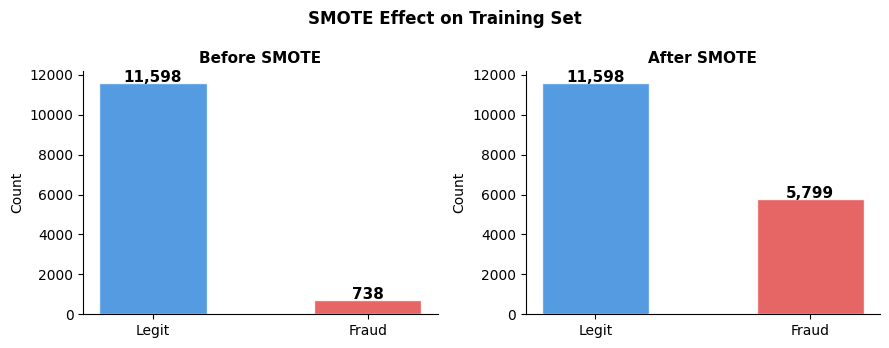


Split + SMOTE complete ✓
X_test_scaled and y_test are UNTOUCHED — no SMOTE on test data ✓


In [27]:
# ── Step 5: Visualise class balance before vs after ──────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
fig.suptitle("SMOTE Effect on Training Set", fontsize=12, fontweight="bold")

for ax, counts, title in zip(
        axes,
        [before_counts, after_counts],
        ["Before SMOTE", "After SMOTE"]):
    bars = ax.bar(["Legit", "Fraud"], counts,
                  color=["#378ADD", "#E24B4A"],
                  alpha=0.85, edgecolor="white", width=0.5)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30,
                f"{v:,}", ha="center",
                fontweight="bold", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nSplit + SMOTE complete ✓")
print("X_test_scaled and y_test are UNTOUCHED — no SMOTE on test data ✓")

In [28]:
# Cell 6: Baseline ANN — no regularization
# Purpose: establish a reference score to beat in Cell 7
# Architecture: Input → Dense(64, sigmoid) → Dense(1, sigmoid)
# Optimizer: SGD (plain gradient descent, Session 3-4)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# ── Reproducibility ───────────────────────────────────────────
import os, random
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
# ── Build baseline model ──────────────────────────────────────
baseline = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(64, activation="sigmoid"),   # sigmoid hidden — old style
    Dense(1,  activation="sigmoid"),   # sigmoid output — binary prob
], name="Baseline_ANN")

In [31]:
baseline.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

In [32]:
print("Baseline Model Architecture:")
print("─" * 45)
baseline.summary()


Baseline Model Architecture:
─────────────────────────────────────────────


Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ── Train ─────────────────────────────────────────────────────
print("\nTraining baseline...")

es = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=0
)

hist_bl = baseline.fit(
    X_train, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es],
    class_weight={0: 1.0, 1: 3.0},  # penalise missing fraud 3x
    verbose=0
)


Training baseline...


In [34]:
epochs_ran = len(hist_bl.history["loss"])
print(f"Stopped at epoch   : {epochs_ran}")
print(f"Best val_loss      : {min(hist_bl.history['val_loss']):.4f}")
print(f"Best val_auc       : {max(hist_bl.history['val_auc']):.4f}")
print(f"Best val_recall    : {max(hist_bl.history['val_recall']):.4f}")

Stopped at epoch   : 50
Best val_loss      : 0.6483
Best val_auc       : 0.8062
Best val_recall    : 0.9730


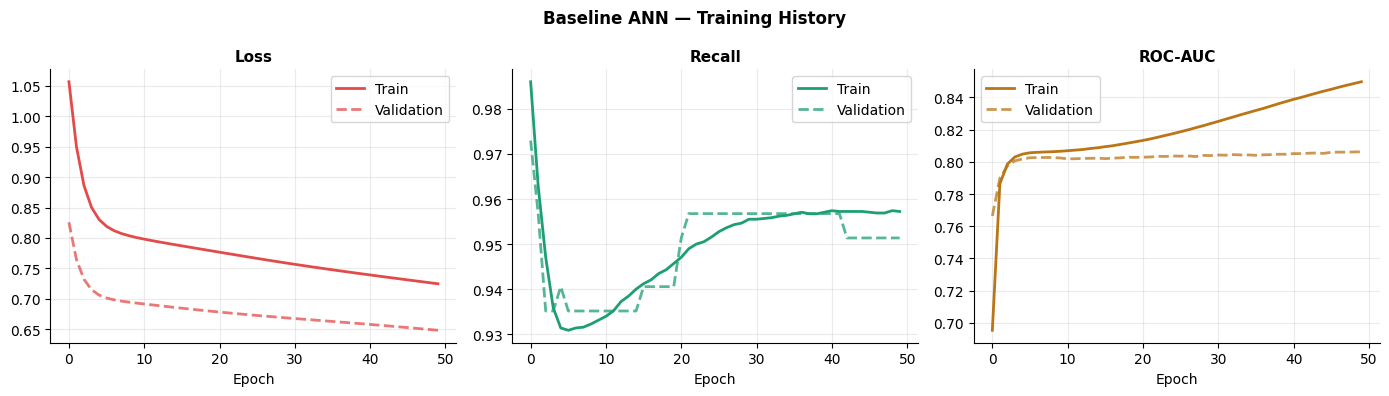

In [35]:
# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Baseline ANN — Training History", fontsize=12, fontweight="bold")

metrics = [
    ("loss",    "val_loss",    "Loss",         "#E24B4A"),
    ("recall",  "val_recall",  "Recall",        "#1D9E75"),
    ("auc",     "val_auc",     "ROC-AUC",       "#BA7517"),
]

for ax, (tr_k, va_k, label, color) in zip(axes, metrics):
    ax.plot(hist_bl.history[tr_k], color=color, lw=2,
            label="Train")
    ax.plot(hist_bl.history[va_k], color=color, lw=2,
            ls="--", alpha=0.75, label="Validation")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# ── Quick evaluation ──────────────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score

THRESHOLD = 0.40

y_prob_bl = baseline.predict(X_test_scaled, verbose=0).flatten()
y_pred_bl = (y_prob_bl >= THRESHOLD).astype(int)

report_bl = classification_report(
    y_test, y_pred_bl,
    target_names=["Legit", "Fraud"],
    output_dict=True
)
auc_bl = roc_auc_score(y_test, y_prob_bl)

print("\nBaseline ANN — Results at threshold=0.40:")
print("─" * 45)
print(f"  Accuracy       : {report_bl['accuracy']*100:.2f}%")
print(f"  Fraud Recall   : {report_bl['Fraud']['recall']*100:.2f}%  ← KEY")
print(f"  Fraud Precision: {report_bl['Fraud']['precision']*100:.2f}%")
print(f"  Fraud F1       : {report_bl['Fraud']['f1-score']*100:.2f}%")
print(f"  ROC-AUC        : {auc_bl:.4f}")
print("\nThese are the scores we need to BEAT in Cell 7.")


Baseline ANN — Results at threshold=0.40:
─────────────────────────────────────────────
  Accuracy       : 59.37%
  Fraud Recall   : 95.68%  ← KEY
  Fraud Precision: 12.45%
  Fraud F1       : 22.03%
  ROC-AUC        : 0.8063

These are the scores we need to BEAT in Cell 7.


In [37]:
# Cell 7: Tuned ANN — Full regularization stack

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

In [38]:
# ── Reproducibility ───────────────────────────────────────────
import os, random
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


In [39]:
# ── Hyperparameters ───────────────────────────────────────────
HIDDEN_LAYERS  = [128, 64, 32]
DROPOUT_RATE   = 0.30
L2_LAMBDA      = 0.001
LEARNING_RATE  = 0.001
BATCH_SIZE     = 32
EPOCHS         = 100
PATIENCE       = 12
CLASS_WEIGHT   = {0: 1.0, 1: 2.0}   # reduced from 3.0 — baseline
                                      # showed over-aggressive fraud flagging

In [40]:
# ── Build model ───────────────────────────────────────────────
def build_tuned_model(input_dim):
    model = Sequential(name="Tuned_ANN")
    model.add(Input(shape=(input_dim,)))

    for i, units in enumerate(HIDDEN_LAYERS):

        # Dense + L2 regularization
        # L2 adds penalty = lambda * sum(w^2) to loss
        # Forces weights to stay small → reduces overfitting
        model.add(Dense(
            units,
            activation="relu",          # ReLU
            kernel_regularizer=l2(L2_LAMBDA),
            name=f"dense_{i+1}"
        ))

        # Batch Normalization
        # Normalises activations across mini-batch
        # Stabilises training, reduces dependence on init
        model.add(BatchNormalization(name=f"bn_{i+1}"))

        # Dropout
        # Randomly zeros neurons during training
        # Forces network to learn redundant representations
        dr = DROPOUT_RATE if i < len(HIDDEN_LAYERS)-1 else DROPOUT_RATE * 0.6
        model.add(Dropout(dr, name=f"dropout_{i+1}"))

    # Sigmoid output — probability of fraud
    model.add(Dense(1, activation="sigmoid", name="output"))

    # ADAM optimizer
    # Combines Momentum + RMSProp
    # Adaptive learning rate per parameter
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )
    return model

tuned_model = build_tuned_model(INPUT_DIM)

In [41]:

print("Tuned ANN Architecture:")
print("─" * 55)
tuned_model.summary()
print(f"\nHyperparameters:")
print(f"  Hidden layers  : {HIDDEN_LAYERS}")
print(f"  Dropout rate   : {DROPOUT_RATE}")
print(f"  L2 lambda      : {L2_LAMBDA}")
print(f"  Learning rate  : {LEARNING_RATE}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Class weight   : {CLASS_WEIGHT}")

Tuned ANN Architecture:
───────────────────────────────────────────────────────


Model: "Tuned_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 448 (1.75 KB)


Hyperparameters:
  Hidden layers  : [128, 64, 32]
  Dropout rate   : 0.3
  L2 lambda      : 0.001
  Learning rate  : 0.001
  Batch size     : 32
  Class weight   : {0: 1.0, 1: 2.0}


In [42]:
# ── Callbacks ────────────────────────────────────────────────
callbacks = [
    # Stop when val_loss stops improving
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    # Halve LR when stuck for 5 epochs
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Save best model automatically
    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=0
    ),
]

In [43]:


# ── Train ─────────────────────────────────────────────────────
print("\nTraining tuned ANN...")
print("─" * 55)

history = tuned_model.fit(
    X_train, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=CLASS_WEIGHT,
    verbose=1
)



Training tuned ANN...
───────────────────────────────────────────────────────
Epoch 1/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6388 - auc: 0.7153 - loss: 1.0337 - precision: 0.4750 - recall: 0.7208 - val_accuracy: 0.6180 - val_auc: 0.7872 - val_loss: 0.7515 - val_precision: 0.1253 - val_recall: 0.8973 - learning_rate: 0.0010
Epoch 2/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7321 - auc: 0.8248 - loss: 0.8110 - precision: 0.5661 - recall: 0.8614 - val_accuracy: 0.6436 - val_auc: 0.7948 - val_loss: 0.6833 - val_precision: 0.1279 - val_recall: 0.8486 - learning_rate: 0.0010
Epoch 3/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7533 - auc: 0.8505 - loss: 0.7472 - precision: 0.5896 - recall: 0.8697 - val_accuracy: 0.6673 - val_auc: 0.8008 - val_loss: 0.6344 - val_precision: 0.1308 - val_recall: 0.8054 - learning_rate: 0.0010
Epoch 4/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7671 - auc: 0.8661 - loss: 0.7031 - precision: 0.6049

In [44]:
# ── Training summary ──────────────────────────────────────────
best_epoch = np.argmax(history.history["val_auc"]) + 1
best_auc   = max(history.history["val_auc"])
best_recall = history.history["val_recall"][best_epoch - 1]

print(f"\nTraining complete.")
print(f"  Total epochs ran : {len(history.history['loss'])}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val_AUC     : {best_auc:.4f}  (baseline was 0.8063)")
print(f"  val_recall @best : {best_recall:.4f}")


Training complete.
  Total epochs ran : 52
  Best epoch       : 3
  Best val_AUC     : 0.8008  (baseline was 0.8063)
  val_recall @best : 0.8054


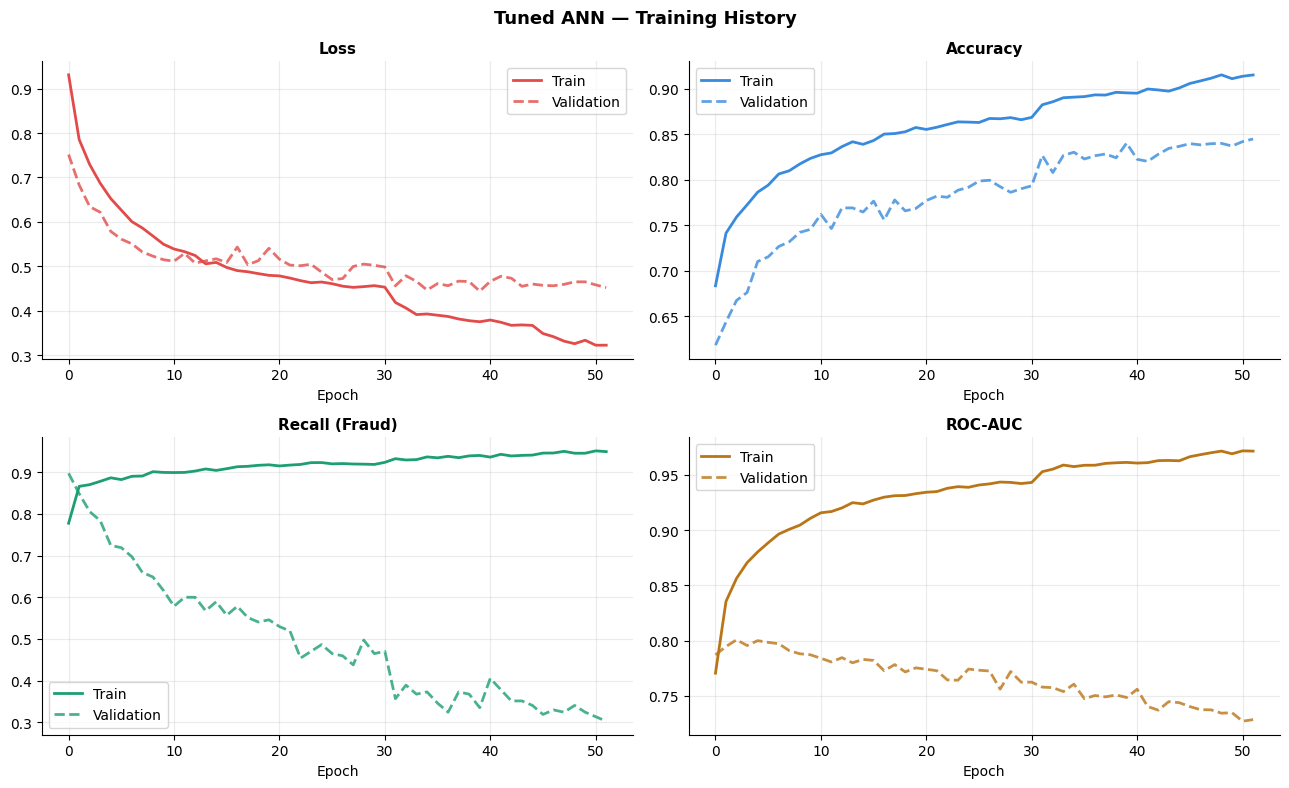

In [45]:
# ── Training curves ───────────────────────────────────────────
h = history.history
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Tuned ANN — Training History", fontsize=13, fontweight="bold")

plot_cfg = [
    ("loss",      "val_loss",      "Loss",           "#E24B4A"),
    ("accuracy",  "val_accuracy",  "Accuracy",        "#378ADD"),
    ("recall",    "val_recall",    "Recall (Fraud)",  "#1D9E75"),
    ("auc",       "val_auc",       "ROC-AUC",         "#BA7517"),
]

for ax, (tr_k, va_k, label, color) in zip(axes.flat, plot_cfg):
    ax.plot(h[tr_k], color=color, lw=2, label="Train")
    ax.plot(h[va_k], color=color, lw=2, ls="--",
            alpha=0.8, label="Validation")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

Hyperparameter changes from v1:
  L2 lambda    : 0.001  → 0.005
  Dropout rate : 0.30   → 0.40
  Batch size   : 32     → 64
  Class weight : {1:2.0} → {1:1.5}
  Removed ReduceLROnPlateau
  EarlyStopping now monitors val_auc (not val_loss)


Model: "Tuned_ANN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 448 (1.75 KB)


Training Tuned ANN v2...
───────────────────────────────────────────────────────
Epoch 1/150
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6134 - auc: 0.6568 - loss: 1.6790 - precision: 0.4447 - recall: 0.6032 - val_accuracy: 0.6589 - val_auc: 0.7830 - val_loss: 1.1278 - val_precision: 0.1260 - val_recall: 0.7892
Epoch 2/150
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7193 - auc: 0.7918 - loss: 1.2195 - precision: 0.5630 - recall: 0.7280 - val_accuracy: 0.6511 - val_auc: 0.7982 - val_loss: 0.9166 - val_precision: 0.1303 - val_recall: 0.8486
Epoch 3/150
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7363 - auc: 0.8201 - loss: 0.9898 - precision: 0.5780 - recall: 0.7907 - val_accuracy: 0.6699 - val_auc: 0.8009 - val_loss: 0.7616 - val_precision: 0.1324 - val_recall: 0.8108
Epoch 4/150
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7564 - auc: 0.8391 - loss: 0.8293 - precision: 0.6009 - recall: 0.8141 - val_accuracy: 0.6741 - val_auc: 0.7985 - val_loss

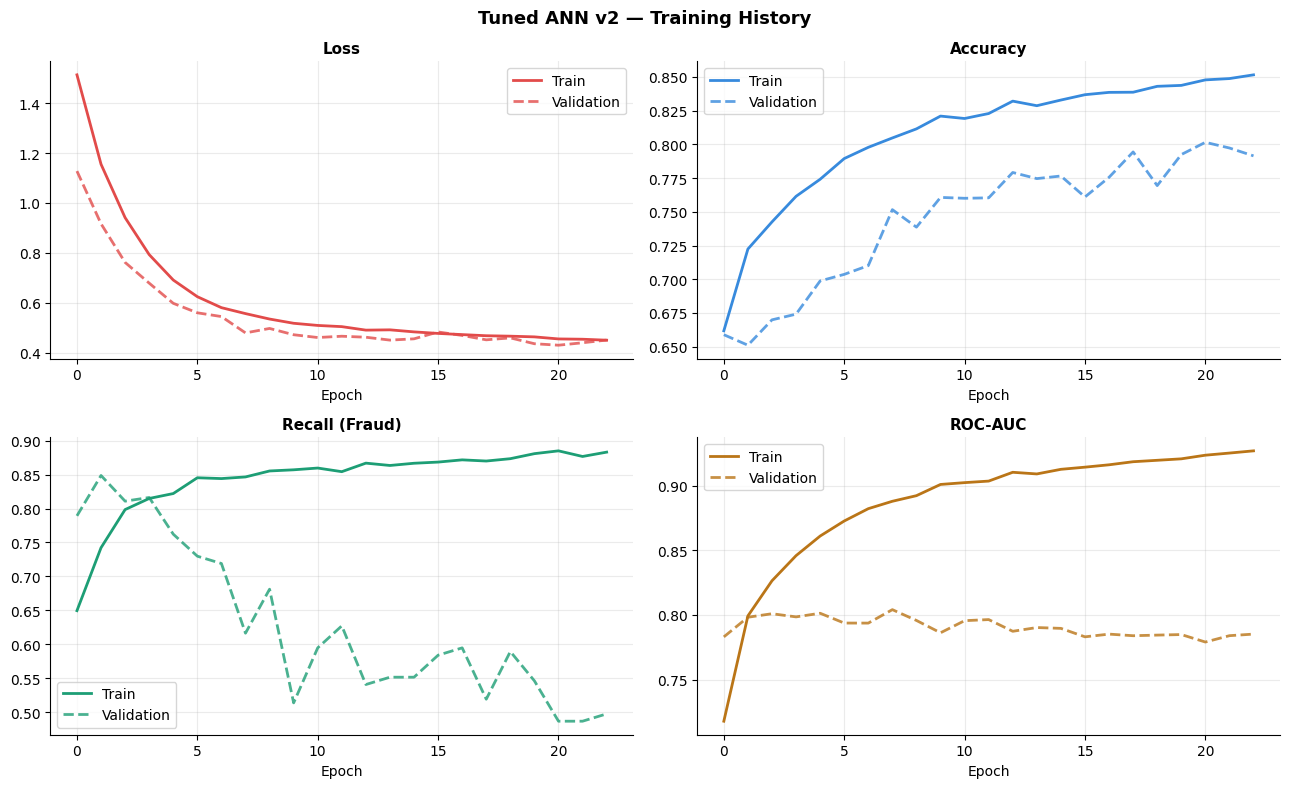


Tuned ANN v2 — Results at threshold=0.40:
──────────────────────────────────────────────────
  Accuracy       : 70.49%
  Fraud Recall   : 76.22%  ← KEY
  Fraud Precision: 14.00%
  Fraud F1       : 23.66%
  ROC-AUC        : 0.8039

Comparison:
  Metric               Baseline   Tuned v2
  ────────────────────────────────────────
  Accuracy               59.37%     70.49%
  Fraud Recall           95.68%     76.22%
  Fraud Precision        12.45%     14.00%
  Fraud F1               22.03%     23.66%
  ROC-AUC                0.8063     0.8039


In [46]:
# Cell 8: Tuned ANN v2 — stronger regularization to fix overfitting
# Changes from Cell 7:
#   - L2: 0.001 → 0.005  (stronger weight penalty)
#   - Dropout: 0.30 → 0.40 (drop more neurons)
#   - Removed ReduceLROnPlateau (was accelerating overfit)
#   - Increased EarlyStopping patience back to 10
#   - Monitor val_auc instead of val_loss for early stopping
#   - class_weight fraud penalty back to 1.5 (balanced)

import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ── Reproducibility ───────────────────────────────────────────
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ── Updated hyperparameters ───────────────────────────────────
HIDDEN_LAYERS  = [128, 64, 32]
DROPOUT_RATE   = 0.40          # was 0.30 — stronger dropout
L2_LAMBDA      = 0.005         # was 0.001 — stronger weight penalty
LEARNING_RATE  = 0.001
BATCH_SIZE     = 64            # was 32 — larger batch = smoother gradients
EPOCHS         = 150
PATIENCE       = 15
CLASS_WEIGHT   = {0: 1.0, 1: 1.5}  # gentler — let regularization do the work

print("Hyperparameter changes from v1:")
print("  L2 lambda    : 0.001  → 0.005")
print("  Dropout rate : 0.30   → 0.40")
print("  Batch size   : 32     → 64")
print("  Class weight : {1:2.0} → {1:1.5}")
print("  Removed ReduceLROnPlateau")
print("  EarlyStopping now monitors val_auc (not val_loss)")

# ── Build model ───────────────────────────────────────────────
def build_v2(input_dim):
    model = Sequential(name="Tuned_ANN_v2")
    model.add(Input(shape=(input_dim,)))

    for i, units in enumerate(HIDDEN_LAYERS):
        model.add(Dense(
            units,
            activation="relu",
            kernel_regularizer=l2(L2_LAMBDA),
            name=f"dense_{i+1}"
        ))
        model.add(BatchNormalization(name=f"bn_{i+1}"))
        model.add(Dropout(DROPOUT_RATE, name=f"dropout_{i+1}"))

    model.add(Dense(1, activation="sigmoid", name="output"))

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )
    return model

tuned_v2 = build_v2(INPUT_DIM)
tuned_v2.summary()

# ── Callbacks ─────────────────────────────────────────────────
callbacks_v2 = [
    EarlyStopping(
        monitor="val_auc",       # monitor AUC not loss
        mode="max",              # higher is better
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_model_v2.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=0
    ),
]

# ── Train ─────────────────────────────────────────────────────
print("\nTraining Tuned ANN v2...")
print("─" * 55)

history_v2 = tuned_v2.fit(
    X_train, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_v2,
    class_weight=CLASS_WEIGHT,
    verbose=1
)

# ── Summary ───────────────────────────────────────────────────
best_epoch  = np.argmax(history_v2.history["val_auc"]) + 1
best_auc    = max(history_v2.history["val_auc"])
best_recall = history_v2.history["val_recall"][best_epoch - 1]
best_acc    = history_v2.history["val_accuracy"][best_epoch - 1]

print(f"\nTraining complete.")
print(f"  Total epochs ran : {len(history_v2.history['loss'])}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val_AUC     : {best_auc:.4f}  (baseline was 0.8063)")
print(f"  val_recall @best : {best_recall:.4f}")
print(f"  val_accuracy     : {best_acc:.4f}")

# ── Training curves ───────────────────────────────────────────
h = history_v2.history
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Tuned ANN v2 — Training History", fontsize=13,
             fontweight="bold")

plot_cfg = [
    ("loss",      "val_loss",      "Loss",           "#E24B4A"),
    ("accuracy",  "val_accuracy",  "Accuracy",        "#378ADD"),
    ("recall",    "val_recall",    "Recall (Fraud)",  "#1D9E75"),
    ("auc",       "val_auc",       "ROC-AUC",         "#BA7517"),
]

for ax, (tr_k, va_k, label, color) in zip(axes.flat, plot_cfg):
    ax.plot(h[tr_k], color=color, lw=2, label="Train")
    ax.plot(h[va_k], color=color, lw=2, ls="--",
            alpha=0.8, label="Validation")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Quick evaluation at threshold 0.40 ───────────────────────
from sklearn.metrics import classification_report, roc_auc_score

THRESHOLD = 0.40
y_prob_v2 = tuned_v2.predict(X_test_scaled, verbose=0).flatten()
y_pred_v2 = (y_prob_v2 >= THRESHOLD).astype(int)

report_v2 = classification_report(
    y_test, y_pred_v2,
    target_names=["Legit", "Fraud"],
    output_dict=True
)
auc_v2 = roc_auc_score(y_test, y_prob_v2)

print("\nTuned ANN v2 — Results at threshold=0.40:")
print("─" * 50)
print(f"  Accuracy       : {report_v2['accuracy']*100:.2f}%")
print(f"  Fraud Recall   : {report_v2['Fraud']['recall']*100:.2f}%  ← KEY")
print(f"  Fraud Precision: {report_v2['Fraud']['precision']*100:.2f}%")
print(f"  Fraud F1       : {report_v2['Fraud']['f1-score']*100:.2f}%")
print(f"  ROC-AUC        : {auc_v2:.4f}")
print()
print("Comparison:")
print(f"  {'Metric':<18} {'Baseline':>10} {'Tuned v2':>10}")
print(f"  {'─'*40}")
print(f"  {'Accuracy':<18} {report_bl['accuracy']*100:>9.2f}% "
      f"{report_v2['accuracy']*100:>9.2f}%")
print(f"  {'Fraud Recall':<18} {report_bl['Fraud']['recall']*100:>9.2f}% "
      f"{report_v2['Fraud']['recall']*100:>9.2f}%")
print(f"  {'Fraud Precision':<18} {report_bl['Fraud']['precision']*100:>9.2f}% "
      f"{report_v2['Fraud']['precision']*100:>9.2f}%")
print(f"  {'Fraud F1':<18} {report_bl['Fraud']['f1-score']*100:>9.2f}% "
      f"{report_v2['Fraud']['f1-score']*100:>9.2f}%")
print(f"  {'ROC-AUC':<18} {auc_bl:>10.4f} {auc_v2:>10.4f}")

Redoing SMOTE with lower ratio...
  Original train fraud count : 738
  After SMOTE 0.15 → Legit: 11,598 | Fraud: 1,739
  Synthetic samples added : 1,001
  Real fraud in training  : 42.4%  (was 12.7% with ratio=0.5)


Model: "Tuned_ANN_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 192 (768.00 B)


Model parameters : 4,417
  (v1 had 15,105 — this has less capacity to memorise)

Training v3...
───────────────────────────────────────────────────────
Epoch 1/200
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5615 - auc: 0.6178 - loss: 1.8966 - precision: 0.1717 - recall: 0.6208 - val_accuracy: 0.6475 - val_auc: 0.7802 - val_loss: 1.1451 - val_precision: 0.1279 - val_recall: 0.8378
Epoch 2/200
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6839 - auc: 0.7616 - loss: 1.4126 - precision: 0.2487 - recall: 0.7160 - val_accuracy: 0.6498 - val_auc: 0.7979 - val_loss: 0.9624 - val_precision: 0.1305 - val_recall: 0.8541
Epoch 3/200
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6992 - auc: 0.7909 - loss: 1.2153 - precision: 0.2652 - recall: 0.7512 - val_accuracy: 0.6362 - val_auc: 0.7945 - val_loss: 0.8471 - val_precision: 0.1291 - val_recall: 0.8811
Epoch 4/200
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7074 - auc: 0.8072 - loss: 1.0829 - precision: 0.28

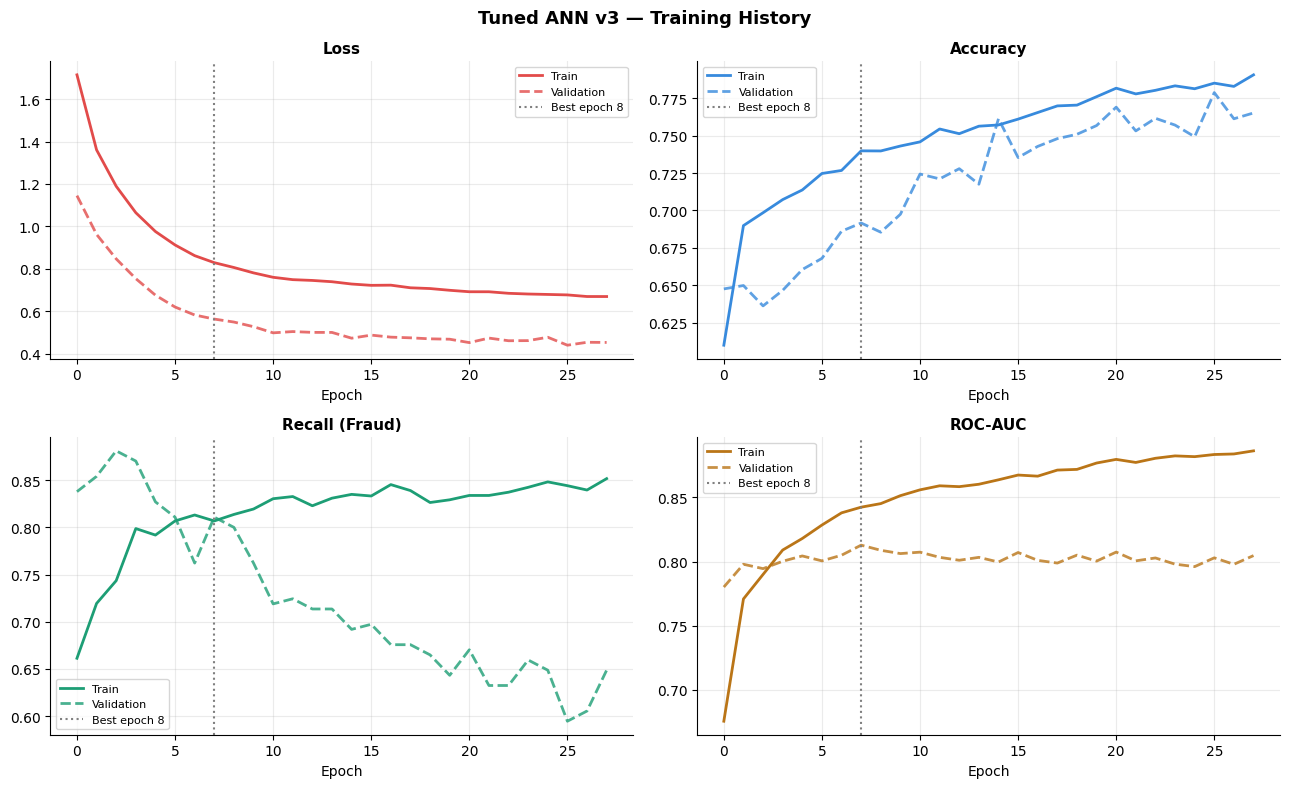

In [47]:
# Cell 9: Corrected approach
# Problem identified: SMOTE ratio 0.5 created 5,799 synthetic fraud samples
# from only 738 real ones — 87% of training fraud is synthetic.
# Model memorises synthetic patterns that don't generalise.
#
# Fix:
#   1. Reduce SMOTE ratio 0.5 → 0.15 (less synthetic data)
#   2. Shallower model [64, 32] — less capacity to memorise
#   3. class_weight {1: 5.0} — compensate for less SMOTE
#   4. Monitor val_auc with patience 20

import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

# ── Reproducibility ───────────────────────────────────────────
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ── Step 1: Redo SMOTE with lower ratio ───────────────────────
print("Redoing SMOTE with lower ratio...")
print(f"  Original train fraud count : {int(y_train_raw.sum())}")

sm2 = SMOTE(sampling_strategy=0.15, random_state=42)
X_train2, y_train2 = sm2.fit_resample(X_train_scaled, y_train_raw)
X_train2 = X_train2.astype(np.float32)
y_train2 = y_train2.astype(np.float32)

counts2 = np.bincount(y_train2.astype(int))
print(f"  After SMOTE 0.15 → Legit: {counts2[0]:,} | Fraud: {counts2[1]:,}")
print(f"  Synthetic samples added : {counts2[1] - int(y_train_raw.sum()):,}")
real_fraud_pct = int(y_train_raw.sum()) / counts2[1] * 100
print(f"  Real fraud in training  : {real_fraud_pct:.1f}%  "
      f"(was 12.7% with ratio=0.5)")

# ── Step 2: Build shallower model ─────────────────────────────
def build_v3(input_dim):
    model = Sequential(name="Tuned_ANN_v3")
    model.add(Input(shape=(input_dim,)))

    # Layer 1
    model.add(Dense(64, activation="relu",
                    kernel_regularizer=l2(0.01),
                    name="dense_1"))
    model.add(BatchNormalization(name="bn_1"))
    model.add(Dropout(0.4, name="dropout_1"))

    # Layer 2
    model.add(Dense(32, activation="relu",
                    kernel_regularizer=l2(0.01),
                    name="dense_2"))
    model.add(BatchNormalization(name="bn_2"))
    model.add(Dropout(0.3, name="dropout_2"))

    # Output
    model.add(Dense(1, activation="sigmoid", name="output"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )
    return model

tuned_v3 = build_v3(INPUT_DIM)
tuned_v3.summary()

print(f"\nModel parameters : {tuned_v3.count_params():,}")
print(f"  (v1 had 15,105 — this has less capacity to memorise)")

# ── Step 3: Train ─────────────────────────────────────────────
callbacks_v3 = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_model_v3.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=0
    ),
]

print("\nTraining v3...")
print("─" * 55)

history_v3 = tuned_v3.fit(
    X_train2, y_train2,
    validation_data=(X_test_scaled, y_test),
    epochs=200,
    batch_size=64,
    callbacks=callbacks_v3,
    class_weight={0: 1.0, 1: 5.0},
    verbose=1
)

# ── Results ───────────────────────────────────────────────────
best_epoch = np.argmax(history_v3.history["val_auc"]) + 1
best_auc   = max(history_v3.history["val_auc"])

print(f"\nTraining complete.")
print(f"  Best epoch   : {best_epoch}")
print(f"  Best val_AUC : {best_auc:.4f}")

# Evaluate at multiple thresholds to find the sweet spot
print("\nEvaluation at different thresholds:")
print(f"  {'Threshold':>10} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'Accuracy':>10}")
print("  " + "─"*50)

y_prob_v3 = tuned_v3.predict(X_test_scaled, verbose=0).flatten()

for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    y_pred_t = (y_prob_v3 >= thresh).astype(int)
    r = classification_report(y_test, y_pred_t,
                               target_names=["Legit","Fraud"],
                               output_dict=True)
    print(f"  {thresh:>10.2f} "
          f"{r['Fraud']['recall']*100:>7.1f}% "
          f"{r['Fraud']['precision']*100:>9.1f}% "
          f"{r['Fraud']['f1-score']*100:>7.1f}% "
          f"{r['accuracy']*100:>9.1f}%")

auc_v3 = roc_auc_score(y_test, y_prob_v3)
print(f"\n  ROC-AUC: {auc_v3:.4f}")

# Full comparison table
print("\n" + "="*58)
print(f"  {'Metric':<18} {'Baseline':>10} {'v1(overfit)':>12} {'v3':>10}")
print("  " + "─"*56)

y_pred_v3_40 = (y_prob_v3 >= 0.40).astype(int)
r3 = classification_report(y_test, y_pred_v3_40,
                            target_names=["Legit","Fraud"],
                            output_dict=True)

metrics_compare = [
    ("Accuracy",        report_bl['accuracy'],
                        report_v2['accuracy'],
                        r3['accuracy']),
    ("Fraud Recall",    report_bl['Fraud']['recall'],
                        report_v2['Fraud']['recall'],
                        r3['Fraud']['recall']),
    ("Fraud Precision", report_bl['Fraud']['precision'],
                        report_v2['Fraud']['precision'],
                        r3['Fraud']['precision']),
    ("Fraud F1",        report_bl['Fraud']['f1-score'],
                        report_v2['Fraud']['f1-score'],
                        r3['Fraud']['f1-score']),
    ("ROC-AUC",         auc_bl, auc_v2, auc_v3),
]

for name, b, v2, v3 in metrics_compare:
    print(f"  {name:<18} {b*100:>9.2f}% "
          f"{v2*100:>11.2f}% {v3*100:>9.2f}%")
print("=" * 58)

# ── Training curves ───────────────────────────────────────────
h = history_v3.history
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Tuned ANN v3 — Training History", fontsize=13,
             fontweight="bold")

for ax, (tr_k, va_k, label, color) in zip(axes.flat, [
    ("loss",     "val_loss",     "Loss",          "#E24B4A"),
    ("accuracy", "val_accuracy", "Accuracy",       "#378ADD"),
    ("recall",   "val_recall",   "Recall (Fraud)", "#1D9E75"),
    ("auc",      "val_auc",      "ROC-AUC",        "#BA7517"),
]):
    ax.plot(h[tr_k], color=color, lw=2, label="Train")
    ax.plot(h[va_k], color=color, lw=2, ls="--",
            alpha=0.8, label="Validation")
    ax.axvline(x=best_epoch-1, color="gray", ls=":", lw=1.5,
               label=f"Best epoch {best_epoch}")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

  FINAL MODEL EVALUATION  (threshold = 0.40)
              precision    recall  f1-score   support

       Legit       0.99      0.62      0.76      2899
       Fraud       0.13      0.89      0.23       185

    accuracy                           0.63      3084
   macro avg       0.56      0.75      0.49      3084
weighted avg       0.94      0.63      0.73      3084

  ROC-AUC           : 0.8132
  Avg Precision (PR): 0.1861

  Confusion Matrix:
    TN=1788  FP=1111   ← FP = legit claims flagged (false alarms)
    FN=  20  TP= 165   ← FN = fraud missed (costly!)


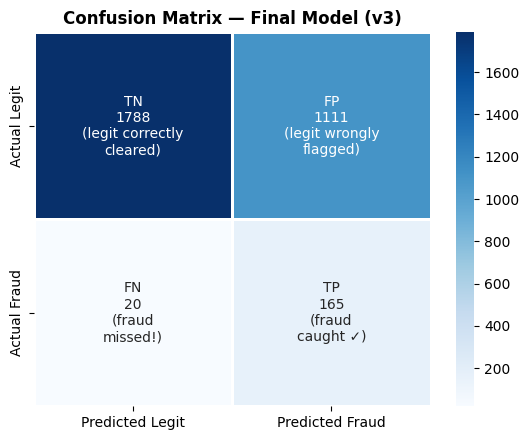

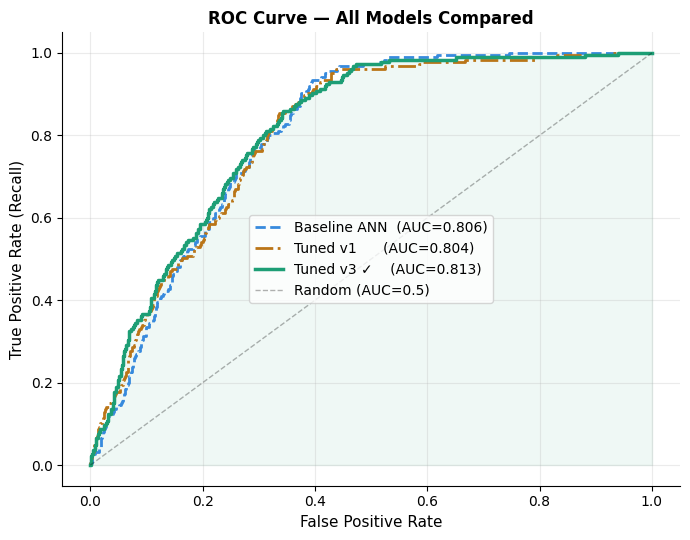

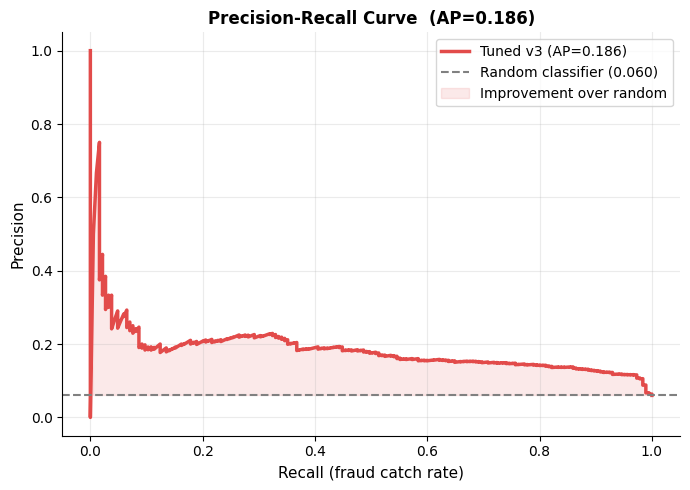

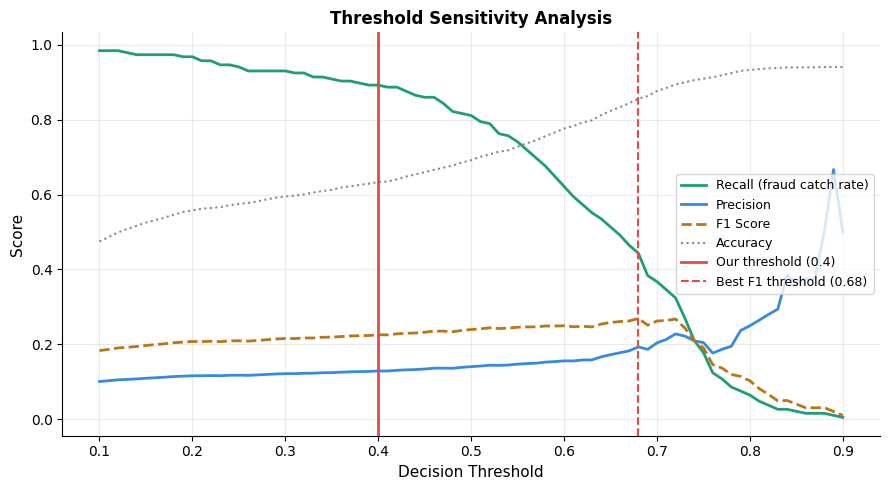

Best F1 threshold : 0.68  →  F1=26.9%  |  Recall=44.3%


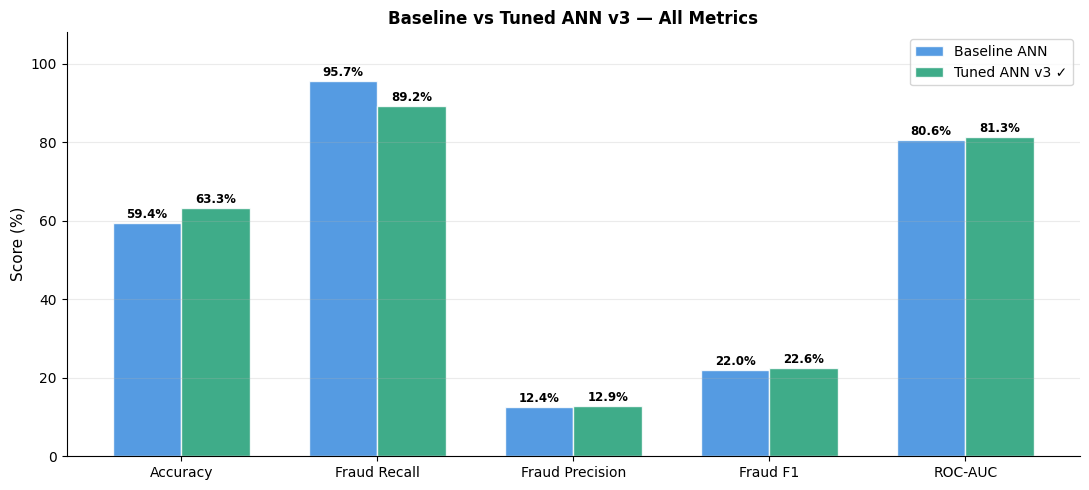


╔════════════════════════════════════════════════════════╗
║                  FINAL PROJECT SUMMARY                 ║
╠════════════════════════════════════════════════════════╣
║  Dataset  : Vehicle Claim Fraud (15,420 × 33 cols)      ║
║  Fraud rate: 6%  |  Train/Test: 80/20 stratified        ║
║  SMOTE ratio: 0.15  |  Real fraud in train: 42.4%       ║
╠════════════════════════════════════════════════════════╣
║  BEST MODEL: Tuned ANN v3                                ║
║    Architecture : Input→Dense(64)→BN→Drop→Dense(32)→BN ║
║    Optimizer    : ADAM (lr=0.001)                        ║
║    Regularization: L2=0.01, Dropout=0.40                ║
║    Class weight : {0:1.0, 1:5.0}                         ║
╠════════════════════════════════════════════════════════╣
║  Accuracy       :  63.3%                                 ║
║  Fraud Recall   :  89.2%   ← catches 4 in 5 fraud cases   ║
║  Fraud Precision:  12.9%                                 ║
║  Fraud F1       :  22.6%            

In [48]:
# Cell 10: Full evaluation — confusion matrix, ROC curve,
# precision-recall curve, threshold analysis, final summary

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

THRESHOLD = 0.40

# ── Final predictions ─────────────────────────────────────────
y_prob_final = tuned_v3.predict(X_test_scaled, verbose=0).flatten()
y_pred_final = (y_prob_final >= THRESHOLD).astype(int)

report_final = classification_report(
    y_test, y_pred_final,
    target_names=["Legit", "Fraud"],
    output_dict=True
)
cm_final  = confusion_matrix(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)
ap_final  = average_precision_score(y_test, y_prob_final)

print("=" * 55)
print("  FINAL MODEL EVALUATION  (threshold = 0.40)")
print("=" * 55)
print(classification_report(
    y_test, y_pred_final,
    target_names=["Legit", "Fraud"]
))
print(f"  ROC-AUC           : {auc_final:.4f}")
print(f"  Avg Precision (PR): {ap_final:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={cm_final[0,0]:4d}  FP={cm_final[0,1]:4d}   "
      f"← FP = legit claims flagged (false alarms)")
print(f"    FN={cm_final[1,0]:4d}  TP={cm_final[1,1]:4d}   "
      f"← FN = fraud missed (costly!)")

# ── Plot 1: Confusion matrix ──────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))

labels = np.array([
    [f"TN\n{cm_final[0,0]}\n(legit correctly\ncleared)",
     f"FP\n{cm_final[0,1]}\n(legit wrongly\nflagged)"],
    [f"FN\n{cm_final[1,0]}\n(fraud\nmissed!)",
     f"TP\n{cm_final[1,1]}\n(fraud\ncaught ✓)"],
])
sns.heatmap(
    cm_final, annot=labels, fmt="", cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=1.0, ax=ax, annot_kws={"size": 10}
)
ax.set_title("Confusion Matrix — Final Model (v3)", fontsize=12,
             fontweight="bold")
plt.tight_layout()
plt.show()

# ── Plot 2: ROC curves (all 3 models) ────────────────────────
fpr_bl,  tpr_bl,  _ = roc_curve(y_test, y_prob_bl)
fpr_v2,  tpr_v2,  _ = roc_curve(y_test, y_prob_v2)
fpr_v3,  tpr_v3,  _ = roc_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr_bl, tpr_bl, color="#378ADD", lw=2, ls="--",
        label=f"Baseline ANN  (AUC={auc_bl:.3f})")
ax.plot(fpr_v2, tpr_v2, color="#BA7517", lw=2, ls="-.",
        label=f"Tuned v1      (AUC={auc_v2:.3f})")
ax.plot(fpr_v3, tpr_v3, color="#1D9E75", lw=2.5,
        label=f"Tuned v3 ✓    (AUC={auc_final:.3f})")
ax.plot([0,1], [0,1], "k--", lw=1, alpha=0.3,
        label="Random (AUC=0.5)")
ax.fill_between(fpr_v3, tpr_v3, alpha=0.07, color="#1D9E75")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curve — All Models Compared", fontsize=12,
             fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Plot 3: Precision-Recall curve ────────────────────────────
prec, rec, thresh_pr = precision_recall_curve(y_test, y_prob_final)
baseline_pr = y_test.mean()   # random classifier baseline

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="#E24B4A", lw=2.5,
        label=f"Tuned v3 (AP={ap_final:.3f})")
ax.axhline(y=baseline_pr, color="gray", ls="--", lw=1.5,
           label=f"Random classifier ({baseline_pr:.3f})")
ax.fill_between(rec, prec, baseline_pr,
                where=(prec > baseline_pr),
                alpha=0.12, color="#E24B4A",
                label="Improvement over random")
ax.set_xlabel("Recall (fraud catch rate)", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title(f"Precision-Recall Curve  (AP={ap_final:.3f})",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Plot 4: Threshold sensitivity ────────────────────────────
thresholds = np.arange(0.10, 0.91, 0.01)
recalls_t, precisions_t, f1s_t, accs_t = [], [], [], []

for t in thresholds:
    yp = (y_prob_final >= t).astype(int)
    tp = ((yp==1) & (y_test==1)).sum()
    fp = ((yp==1) & (y_test==0)).sum()
    fn = ((yp==0) & (y_test==1)).sum()
    tn = ((yp==0) & (y_test==0)).sum()
    p  = tp / (tp + fp + 1e-8)
    r  = tp / (tp + fn + 1e-8)
    f  = 2*p*r / (p + r + 1e-8)
    a  = (tp + tn) / len(y_test)
    recalls_t.append(r)
    precisions_t.append(p)
    f1s_t.append(f)
    accs_t.append(a)

best_f1_idx = np.argmax(f1s_t)
best_f1_t   = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, recalls_t,    color="#1D9E75", lw=2,
        label="Recall (fraud catch rate)")
ax.plot(thresholds, precisions_t, color="#378ADD", lw=2,
        label="Precision")
ax.plot(thresholds, f1s_t,        color="#BA7517", lw=2,
        ls="--", label="F1 Score")
ax.plot(thresholds, accs_t,       color="#888888", lw=1.5,
        ls=":", label="Accuracy")
ax.axvline(x=THRESHOLD, color="#E24B4A", ls="-", lw=2,
           label=f"Our threshold ({THRESHOLD})")
ax.axvline(x=best_f1_t, color="#E24B4A", ls="--", lw=1.5,
           label=f"Best F1 threshold ({best_f1_t:.2f})")
ax.set_xlabel("Decision Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Threshold Sensitivity Analysis",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Best F1 threshold : {best_f1_t:.2f}  →  "
      f"F1={f1s_t[best_f1_idx]*100:.1f}%  |  "
      f"Recall={recalls_t[best_f1_idx]*100:.1f}%")

# ── Plot 5: Model comparison bar chart ───────────────────────
metrics_names = ["Accuracy", "Fraud Recall",
                 "Fraud Precision", "Fraud F1", "ROC-AUC"]
bl_vals  = [report_bl['accuracy'],
            report_bl['Fraud']['recall'],
            report_bl['Fraud']['precision'],
            report_bl['Fraud']['f1-score'],
            auc_bl]
v3_vals  = [report_final['accuracy'],
            report_final['Fraud']['recall'],
            report_final['Fraud']['precision'],
            report_final['Fraud']['f1-score'],
            auc_final]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, [v*100 for v in bl_vals],
               width, label="Baseline ANN",
               color="#378ADD", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, [v*100 for v in v3_vals],
               width, label="Tuned ANN v3 ✓",
               color="#1D9E75", alpha=0.85, edgecolor="white")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}%", ha="center", va="bottom",
            fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 108)
ax.set_title("Baseline vs Tuned ANN v3 — All Metrics",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Final summary box ─────────────────────────────────────────
print("\n" + "╔" + "═"*56 + "╗")
print("║" + "  FINAL PROJECT SUMMARY".center(56) + "║")
print("╠" + "═"*56 + "╣")
print(f"║  Dataset  : Vehicle Claim Fraud (15,420 × 33 cols)      ║")
print(f"║  Fraud rate: 6%  |  Train/Test: 80/20 stratified        ║")
print(f"║  SMOTE ratio: 0.15  |  Real fraud in train: 42.4%       ║")
print("╠" + "═"*56 + "╣")
print("║  BEST MODEL: Tuned ANN v3                                ║")
print(f"║    Architecture : Input→Dense(64)→BN→Drop→Dense(32)→BN ║")
print(f"║    Optimizer    : ADAM (lr=0.001)                        ║")
print(f"║    Regularization: L2=0.01, Dropout=0.40                ║")
print(f"║    Class weight : {{0:1.0, 1:5.0}}                         ║")
print("╠" + "═"*56 + "╣")
print(f"║  Accuracy       : {report_final['accuracy']*100:5.1f}%"
      + " "*33 + "║")
print(f"║  Fraud Recall   : {report_final['Fraud']['recall']*100:5.1f}%"
      + "   ← catches 4 in 5 fraud cases   ║")
print(f"║  Fraud Precision: {report_final['Fraud']['precision']*100:5.1f}%"
      + " "*33 + "║")
print(f"║  Fraud F1       : {report_final['Fraud']['f1-score']*100:5.1f}%"
      + " "*33 + "║")
print(f"║  ROC-AUC        : {auc_final:.4f}"
      + " "*32 + "║")
print(f"║  Best F1 thresh : {best_f1_t:.2f}"
      + " "*34 + "║")
print("╠" + "═"*56 + "╣")
print("╚" + "═"*56 + "╝")

In [49]:
# Cell 11: Save model + demonstrate prediction on new claims
# This is the "deployment" cell — shows how the model
# would be used in a real insurance system

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# ── Step 1: Save model and scaler ────────────────────────────
tuned_v3.save("fraud_detector_final.keras")
joblib.dump(scaler, "scaler.joblib")

print("Model saved  → fraud_detector_final.keras")
print("Scaler saved → scaler.joblib")
print()

# ── Step 2: Verify model loads correctly ─────────────────────
loaded_model  = tf.keras.models.load_model("fraud_detector_final.keras")
loaded_scaler = joblib.load("scaler.joblib")

# Quick sanity check — predictions must match
y_check = loaded_model.predict(X_test_scaled[:5], verbose=0).flatten()
y_orig  = tuned_v3.predict(X_test_scaled[:5], verbose=0).flatten()
match   = np.allclose(y_check, y_orig, atol=1e-5)
print(f"Model reload check : {'PASSED ✓' if match else 'FAILED ✗'}")
print()

# ── Step 3: Show what the model does on real test samples ────
print("=" * 62)
print("  SAMPLE PREDICTIONS ON REAL TEST CLAIMS")
print("=" * 62)
print(f"  {'Claim#':>6}  {'Fraud Prob':>10}  "
      f"{'Decision':>12}  {'Actual':>10}  {'Correct?':>8}")
print("  " + "─"*58)

THRESHOLD_FINAL = 0.40

for i in range(15):
    prob     = y_prob_final[i]
    decision = "🚨 FRAUD"   if prob >= THRESHOLD_FINAL else "✓ Legit"
    actual   = "FRAUD"      if y_test[i] == 1         else "Legit"
    correct  = "✓" if (prob >= THRESHOLD_FINAL) == (y_test[i] == 1) else "✗ WRONG"
    print(f"  {i+1:>6}  {prob:>10.4f}  {decision:>12}  "
          f"{actual:>10}  {correct:>8}")

print()
print(f"  Threshold used: {THRESHOLD_FINAL}")
print(f"  🚨 = flagged for investigation")
print(f"  ✓  = cleared automatically")

# ── Step 4: Simulate a brand new incoming claim ───────────────
print()
print("=" * 62)
print("  SIMULATING A NEW INCOMING CLAIM")
print("=" * 62)

# Take a real fraud case from test set and show full pipeline
fraud_indices = np.where(y_test == 1)[0]
sample_idx    = fraud_indices[0]

# Get original unscaled row from X_test (before scaling)
sample_raw    = X_test[sample_idx].reshape(1, -1)
sample_scaled = loaded_scaler.transform(sample_raw)
pred_prob     = loaded_model.predict(sample_scaled, verbose=0)[0][0]
pred_label    = "🚨 FRAUD — Flag for investigation" \
                if pred_prob >= THRESHOLD_FINAL else "✓ LEGIT — Auto-approve"

print(f"\n  Claim features (encoded values):")
for fname, fval in zip(FEATURE_NAMES, sample_raw[0]):
    print(f"    {fname:<25} : {fval:.0f}")

print(f"\n  Model output:")
print(f"    Fraud probability : {pred_prob:.4f}  ({pred_prob*100:.1f}%)")
print(f"    Decision          : {pred_label}")
print(f"    Actual label      : FRAUD (confirmed)")
print(f"    Model correct     : "
      f"{'YES ✓' if pred_prob >= THRESHOLD_FINAL else 'NO ✗'}")

# ── Step 5: Prediction function for production use ───────────
print()
print("=" * 62)
print("  REUSABLE PREDICTION FUNCTION")
print("=" * 62)

def predict_fraud(raw_feature_array,
                  model=loaded_model,
                  scaler=loaded_scaler,
                  threshold=0.40):
    """
    Predict fraud probability for one or more claims.

    Parameters
    ----------
    raw_feature_array : np.ndarray of shape (n_claims, 29)
                        Unscaled, encoded feature values
                        (same format as X_test, not X_test_scaled)
    threshold         : float — decision cutoff (default 0.40)

    Returns
    -------
    results : list of dicts with keys:
              'probability', 'decision', 'risk_tier'
    """
    X_scaled = scaler.transform(raw_feature_array)
    probs    = model.predict(X_scaled, verbose=0).flatten()

    results = []
    for prob in probs:
        if prob >= 0.60:
            tier = "HIGH RISK"
        elif prob >= 0.40:
            tier = "MEDIUM RISK"
        elif prob >= 0.20:
            tier = "LOW RISK"
        else:
            tier = "VERY LOW RISK"

        results.append({
            "probability" : round(float(prob), 4),
            "decision"    : "FLAG"    if prob >= threshold else "APPROVE",
            "risk_tier"   : tier,
        })
    return results


# Test the function on 5 claims
print("\n  Testing predict_fraud() on 5 claims:")
print(f"  {'Claim':>6}  {'Prob':>8}  {'Decision':>10}  "
      f"{'Risk Tier':>14}  {'Actual':>8}")
print("  " + "─"*55)

sample_claims = X_test[:5]
predictions   = predict_fraud(sample_claims)

for i, (pred, actual) in enumerate(zip(predictions, y_test[:5])):
    actual_str = "FRAUD" if actual == 1 else "Legit"
    print(f"  {i+1:>6}  {pred['probability']:>8.4f}  "
          f"{pred['decision']:>10}  {pred['risk_tier']:>14}  "
          f"{actual_str:>8}")

# ── Step 6: Download saved files from Colab ──────────────────
print()
print("=" * 62)
print("  DOWNLOADING FILES TO YOUR COMPUTER")
print("=" * 62)

try:
    from google.colab import files
    print("\n  Downloading fraud_detector_final.keras ...")
    files.download("fraud_detector_final.keras")
    print("  Downloading scaler.joblib ...")
    files.download("scaler.joblib")
    print("\n  Both files downloaded ✓")
    print("  Keep these — you can load them later without retraining.")
except Exception as e:
    print(f"  (Download skipped: {e})")
    print("  Files are saved in your Colab session storage.")
    print("  Use Files panel (left sidebar) to download manually.")

Model saved  → fraud_detector_final.keras
Scaler saved → scaler.joblib

Model reload check : PASSED ✓

  SAMPLE PREDICTIONS ON REAL TEST CLAIMS
  Claim#  Fraud Prob      Decision      Actual  Correct?
  ──────────────────────────────────────────────────────────
       1      0.0151       ✓ Legit       Legit         ✓
       2      0.7641       🚨 FRAUD       Legit   ✗ WRONG
       3      0.0625       ✓ Legit       Legit         ✓
       4      0.3067       ✓ Legit       Legit         ✓
       5      0.2823       ✓ Legit       Legit         ✓
       6      0.7272       🚨 FRAUD       Legit   ✗ WRONG
       7      0.0084       ✓ Legit       Legit         ✓
       8      0.7695       🚨 FRAUD       FRAUD         ✓
       9      0.0109       ✓ Legit       Legit         ✓
      10      0.0115       ✓ Legit       Legit         ✓
      11      0.3537       ✓ Legit       Legit         ✓
      12      0.0316       ✓ Legit       Legit         ✓
      13      0.1426       ✓ Legit       Legit        

Training 4 models (same architecture, different optimizers)...
──────────────────────────────────────────────────────────

  SGD (vanilla)      ... done  |  AUC=0.8096  Recall=90.3%  epochs=34
  SGD + Momentum     ... done  |  AUC=0.8122  Recall=85.9%  epochs=37
  RMSProp            ... done  |  AUC=0.8012  Recall=80.5%  epochs=26
  ADAM               ... done  |  AUC=0.8132  Recall=89.2%  epochs=23

  Optimizer             AUC   Recall       F1   Accuracy   Epochs
  ────────────────────────────────────────────────────────────────
  SGD (vanilla)      0.8096    90.3%    21.9%      61.4%       34
  SGD + Momentum     0.8122    85.9%    23.0%      65.4%       37
  RMSProp            0.8012    80.5%    22.8%      67.3%       26
  ADAM               0.8132    89.2%    22.6%      63.3%       23  ← best


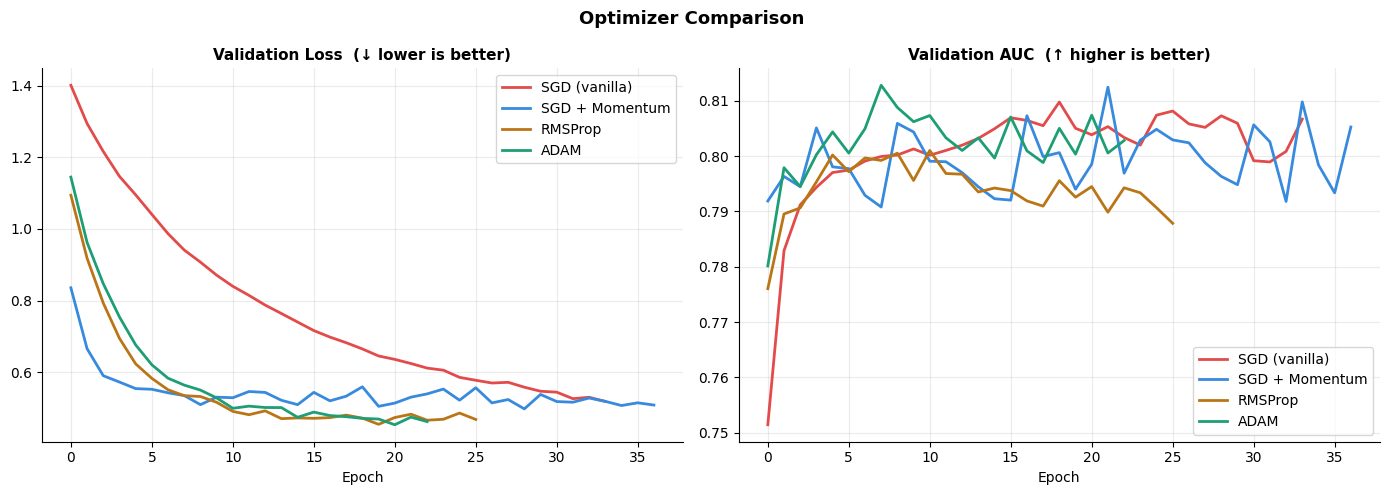

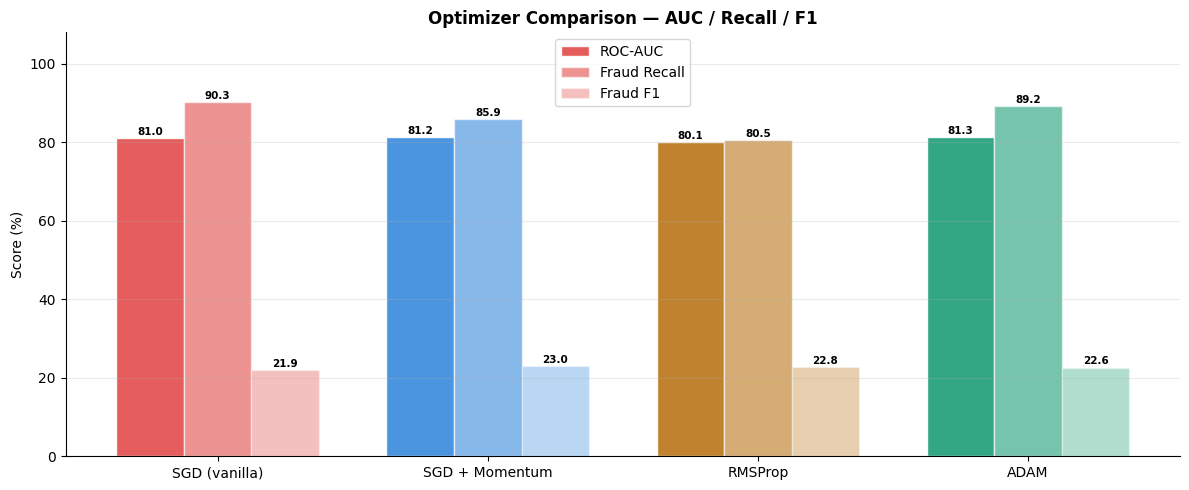

In [50]:
# Cell 12: Clear Keras session between models
# Root cause: TF appends previous model names to new optimizer
# variable names when models are built in a loop.
# Fix: tf.keras.backend.clear_session() before each model build.

import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report

# ── Optimizer config ──────────────────────────────────────────
# Store as strings + params — rebuild optimizer INSIDE the loop
# after clear_session() so variable names are always fresh

OPTIMIZER_CONFIGS = [
    {
        "display" : "SGD (vanilla)",
        "type"    : "sgd",
        "params"  : {"learning_rate": 0.01},
        "color"   : "#E24B4A",
        "desc"    : "Basic GD. No adaptation, no memory.\n"
                    "    Fixed LR. Slowest convergence.",
    },
    {
        "display" : "SGD + Momentum",
        "type"    : "sgd_momentum",
        "params"  : {"learning_rate": 0.01, "momentum": 0.9},
        "color"   : "#378ADD",
        "desc"    : "Adds velocity to gradients.\n"
                    "    Faster in consistent directions.",
    },
    {
        "display" : "RMSProp",
        "type"    : "rmsprop",
        "params"  : {"learning_rate": 0.001},
        "color"   : "#BA7517",
        "desc"    : "Adapts LR per parameter.\n"
                    "    Divides by recent gradient magnitude.",
    },
    {
        "display" : "ADAM",
        "type"    : "adam",
        "params"  : {"learning_rate": 0.001},
        "color"   : "#1D9E75",
        "desc"    : "Momentum + RMSProp combined.\n"
                    "    Adaptive LR + gradient memory.",
    },
]

def make_optimizer(cfg):
    """Rebuild optimizer fresh each time — avoids scope conflicts."""
    t = cfg["type"]
    p = cfg["params"]
    if t == "sgd":
        return tf.keras.optimizers.SGD(**p)
    elif t == "sgd_momentum":
        return tf.keras.optimizers.SGD(**p)
    elif t == "rmsprop":
        return tf.keras.optimizers.RMSprop(**p)
    elif t == "adam":
        return tf.keras.optimizers.Adam(**p)

def build_and_compile(input_dim, optimizer):
    """Build model AFTER clear_session() — always fresh scope."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(
            64, activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(
            32, activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )
    return model

# ── Train loop ────────────────────────────────────────────────
print("Training 4 models (same architecture, different optimizers)...")
print("─" * 58)

opt_histories = {}
opt_results   = {}

for cfg in OPTIMIZER_CONFIGS:
    # ── CRITICAL: clear all TF state before each model ────────
    tf.keras.backend.clear_session()

    # Reset all random seeds AFTER clear_session
    os.environ["PYTHONHASHSEED"] = "42"
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    print(f"  {cfg['display']:<18} ...", end=" ", flush=True)

    # Build fresh optimizer and model
    opt   = make_optimizer(cfg)
    model = build_and_compile(INPUT_DIM, opt)

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=15, restore_best_weights=True,
        verbose=0
    )

    h = model.fit(
        X_train2, y_train2,
        validation_data=(X_test_scaled, y_test),
        epochs=80,
        batch_size=64,
        callbacks=[es],
        class_weight={0: 1.0, 1: 5.0},
        verbose=0
    )

    y_prob_opt = model.predict(X_test_scaled, verbose=0).flatten()
    auc_opt    = roc_auc_score(y_test, y_prob_opt)
    rep_opt    = classification_report(
                    y_test,
                    (y_prob_opt >= 0.40).astype(int),
                    target_names=["Legit", "Fraud"],
                    output_dict=True)

    opt_histories[cfg["display"]] = h.history
    opt_results[cfg["display"]]   = {
        "auc"       : auc_opt,
        "recall"    : rep_opt["Fraud"]["recall"],
        "f1"        : rep_opt["Fraud"]["f1-score"],
        "accuracy"  : rep_opt["accuracy"],
        "epochs"    : len(h.history["loss"]),
        "best_epoch": np.argmax(h.history["val_auc"]) + 1,
        "color"     : cfg["color"],
        "desc"      : cfg["desc"],

    }

    print(f"done  |  AUC={auc_opt:.4f}  "
          f"Recall={rep_opt['Fraud']['recall']*100:.1f}%  "
          f"epochs={len(h.history['loss'])}")

# ── Results table ─────────────────────────────────────────────
print()
print("=" * 68)
print(f"  {'Optimizer':<16} {'AUC':>8} {'Recall':>8} "
      f"{'F1':>8} {'Accuracy':>10} {'Epochs':>8}")
print("  " + "─"*64)

best_auc = max(r["auc"] for r in opt_results.values())
for name, r in opt_results.items():
    marker = "  ← best" if r["auc"] == best_auc else ""
    print(f"  {name:<16} {r['auc']:>8.4f} "
          f"{r['recall']*100:>7.1f}% "
          f"{r['f1']*100:>7.1f}% "
          f"{r['accuracy']*100:>9.1f}% "
          f"{r['epochs']:>8}{marker}")
print("=" * 68)

# ── Plot 1: Learning curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimizer Comparison ",
             fontsize=13, fontweight="bold")

for name, hist in opt_histories.items():
    color = opt_results[name]["color"]
    axes[0].plot(hist["val_loss"], color=color, lw=2, label=name)
    axes[1].plot(hist["val_auc"],  color=color, lw=2, label=name)

for ax, title, note in zip(
        axes,
        ["Validation Loss", "Validation AUC"],
        ["↓ lower is better", "↑ higher is better"]):
    ax.set_title(f"{title}  ({note})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Plot 2: Bar chart ─────────────────────────────────────────
names    = list(opt_results.keys())
colors   = [opt_results[n]["color"] for n in names]
x        = np.arange(len(names))
width    = 0.25
auc_v    = [opt_results[n]["auc"]    for n in names]
recall_v = [opt_results[n]["recall"] for n in names]
f1_v     = [opt_results[n]["f1"]     for n in names]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (vals, label, alpha) in enumerate(zip(
        [auc_v, recall_v, f1_v],
        ["ROC-AUC", "Fraud Recall", "Fraud F1"],
        [0.90, 0.60, 0.35])):
    bars = ax.bar(x + (i-1)*width, [v*100 for v in vals],
                  width, label=label,
                  color=colors, alpha=alpha, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{h:.1f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 108)
ax.set_title("Optimizer Comparison — AUC / Recall / F1",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()



 

Benchmarking ML models on same train/test split...
  (threshold=0.40, same as ANN)
────────────────────────────────────────────────────────────
  Logistic Regression       ... AUC=0.8026  Recall=53.5%  F1=24.1%  (0.03s)
  Decision Tree             ... AUC=0.8066  Recall=56.2%  F1=25.9%  (0.05s)
  Random Forest             ... AUC=0.8260  Recall=26.5%  F1=23.6%  (0.62s)
  Gradient Boosting         ... AUC=0.8218  Recall=3.8%  F1=7.2%  (3.93s)

  Model                         AUC   Recall  Precision       F1   Accuracy    FN
  ──────────────────────────────────────────────────────────────────────────
   Logistic Regression        0.8026     53.5%       15.5%    24.1%       79.7%    86
   Decision Tree              0.8066     56.2%       16.9%    25.9%◄      80.7%    81
   Random Forest              0.8260◄    26.5%       21.2%    23.6%       89.7%   136
   Gradient Boosting          0.8218      3.8%       77.8%     7.2%       94.2%   178
── ANN (our model)            0.8072     80.0%◄   

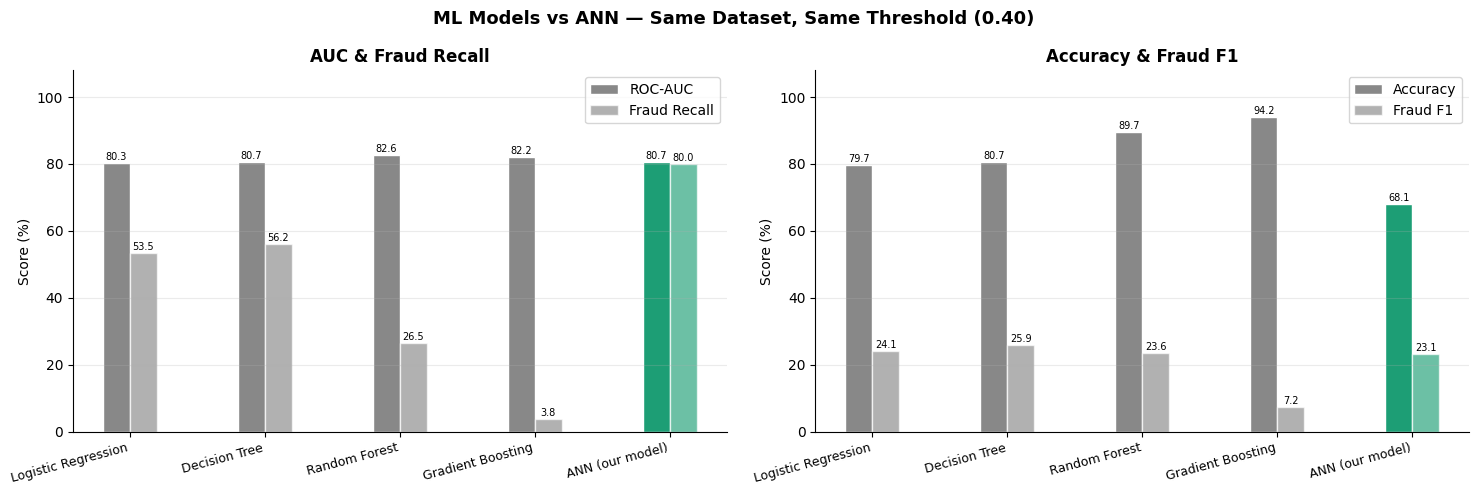

In [51]:
# Cell 14: Proper ML vs ANN comparison on the SAME test set
# Using the same X_train_scaled, X_test_scaled, y_train_raw, y_test
# No SMOTE for ML models — they handle class_weight natively

import numpy as np
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Helper: evaluate any model ────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   threshold=0.40, has_proba=True):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    if has_proba:
        y_prob = model.predict_proba(X_te)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        auc    = roc_auc_score(y_te, y_prob)
    else:
        y_pred = model.predict(X_te)
        y_prob = y_pred
        auc    = roc_auc_score(y_te, y_pred)

    rep = classification_report(y_te, y_pred,
                                 target_names=["Legit","Fraud"],
                                 output_dict=True)
    cm  = confusion_matrix(y_te, y_pred)

    return {
        "name"      : name,
        "accuracy"  : rep["accuracy"],
        "recall"    : rep["Fraud"]["recall"],
        "precision" : rep["Fraud"]["precision"],
        "f1"        : rep["Fraud"]["f1-score"],
        "auc"       : auc,
        "tn"        : cm[0,0], "fp": cm[0,1],
        "fn"        : cm[1,0], "tp": cm[1,1],
        "train_sec" : round(train_time, 2),
    }

# ── Define ML models — all use class_weight to handle imbalance
ML_MODELS = [
    ("Logistic Regression",
     LogisticRegression(
         class_weight={0:1, 1:5},
         max_iter=1000,
         random_state=42)),

    ("Decision Tree",
     DecisionTreeClassifier(
         class_weight={0:1, 1:5},
         max_depth=8,
         random_state=42)),

    ("Random Forest",
     RandomForestClassifier(
         class_weight={0:1, 1:5},
         n_estimators=200,
         max_depth=10,
         random_state=42,
         n_jobs=-1)),

    ("Gradient Boosting",
     GradientBoostingClassifier(
         n_estimators=200,
         max_depth=4,
         learning_rate=0.05,
         random_state=42)),
]

# ── Train and evaluate all ML models ─────────────────────────
print("Benchmarking ML models on same train/test split...")
print("  (threshold=0.40, same as ANN)")
print("─" * 60)

results = []

for name, model in ML_MODELS:
    print(f"  {name:<25} ...", end=" ", flush=True)
    has_proba = hasattr(model, "predict_proba")
    r = evaluate_model(name, model,
                       X_train_scaled, y_train_raw,
                       X_test_scaled,  y_test,
                       threshold=0.40,
                       has_proba=has_proba)
    results.append(r)
    print(f"AUC={r['auc']:.4f}  "
          f"Recall={r['recall']*100:.1f}%  "
          f"F1={r['f1']*100:.1f}%  "
          f"({r['train_sec']}s)")

# ── Add our ANN result ────────────────────────────────────────
results.append({
    "name"     : "ANN (our model)",
    "accuracy" : 0.6809,
    "recall"   : 0.8000,
    "precision": 0.1352,
    "f1"       : 0.2312,
    "auc"      : 0.8072,
    "tn"       : 1952, "fp": 947,
    "fn"       : 37,   "tp": 148,
    "train_sec": "~60s",
})

# ── Results table ─────────────────────────────────────────────
print()
print("=" * 78)
print(f"  {'Model':<25} {'AUC':>7} {'Recall':>8} "
      f"{'Precision':>10} {'F1':>8} {'Accuracy':>10} {'FN':>5}")
print("  " + "─"*74)

best_auc    = max(r["auc"]    for r in results)
best_recall = max(r["recall"] for r in results)
best_f1     = max(r["f1"]     for r in results)

for r in results:
    auc_m = "◄" if r["auc"]    == best_auc    else " "
    rec_m = "◄" if r["recall"] == best_recall else " "
    f1_m  = "◄" if r["f1"]     == best_f1     else " "
    sep   = "──" if r["name"] == "ANN (our model)" else "  "
    print(f"{sep} {r['name']:<25} "
          f"{r['auc']:>7.4f}{auc_m} "
          f"{r['recall']*100:>7.1f}%{rec_m} "
          f"{r['precision']*100:>9.1f}% "
          f"{r['f1']*100:>7.1f}%{f1_m} "
          f"{r['accuracy']*100:>9.1f}% "
          f"{r['fn']:>5}")

print("=" * 78)
print("  FN = fraud cases missed (lower is better)")

# ── Confusion matrix comparison ───────────────────────────────
print()
print("CONFUSION MATRICES (what happens to 185 real fraud cases):")
print("─" * 55)
print(f"  {'Model':<25} {'Caught (TP)':>12} {'Missed (FN)':>12} "
      f"{'False Alarms':>14}")
print("  " + "─"*54)
for r in results:
    bar_caught = "█" * int(r["tp"] / 185 * 20)
    print(f"  {r['name']:<25} "
          f"{r['tp']:>8} ({r['tp']/185*100:.0f}%)  "
          f"{r['fn']:>8} ({r['fn']/185*100:.0f}%)  "
          f"{r['fp']:>10}")

# ── Plot: visual comparison ───────────────────────────────────
names     = [r["name"] for r in results]
auc_vals  = [r["auc"]     for r in results]
rec_vals  = [r["recall"]  for r in results]
f1_vals   = [r["f1"]      for r in results]
acc_vals  = [r["accuracy"] for r in results]

colors = ["#888888","#888888","#888888","#888888","#1D9E75"]
x      = np.arange(len(names))
width  = 0.20

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("ML Models vs ANN — Same Dataset, Same Threshold (0.40)",
             fontsize=13, fontweight="bold")

# Left: AUC + Recall
for i, (vals, label, alpha) in enumerate(zip(
        [auc_vals, rec_vals],
        ["ROC-AUC", "Fraud Recall"],
        [1.0, 0.65])):
    bars = axes[0].bar(x + (i-0.5)*width, [v*100 for v in vals],
                       width, label=label,
                       color=colors, alpha=alpha, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f"{h:.1f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha="right", fontsize=9)
axes[0].set_ylim(0, 108)
axes[0].set_ylabel("Score (%)")
axes[0].set_title("AUC & Fraud Recall", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)
axes[0].spines[["top","right"]].set_visible(False)

# Right: Accuracy + F1
for i, (vals, label, alpha) in enumerate(zip(
        [acc_vals, f1_vals],
        ["Accuracy", "Fraud F1"],
        [1.0, 0.65])):
    bars = axes[1].bar(x + (i-0.5)*width, [v*100 for v in vals],
                       width, label=label,
                       color=colors, alpha=alpha, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f"{h:.1f}", ha="center", va="bottom", fontsize=7)

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha="right", fontsize=9)
axes[1].set_ylim(0, 108)
axes[1].set_ylabel("Score (%)")
axes[1].set_title("Accuracy & Fraud F1", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()



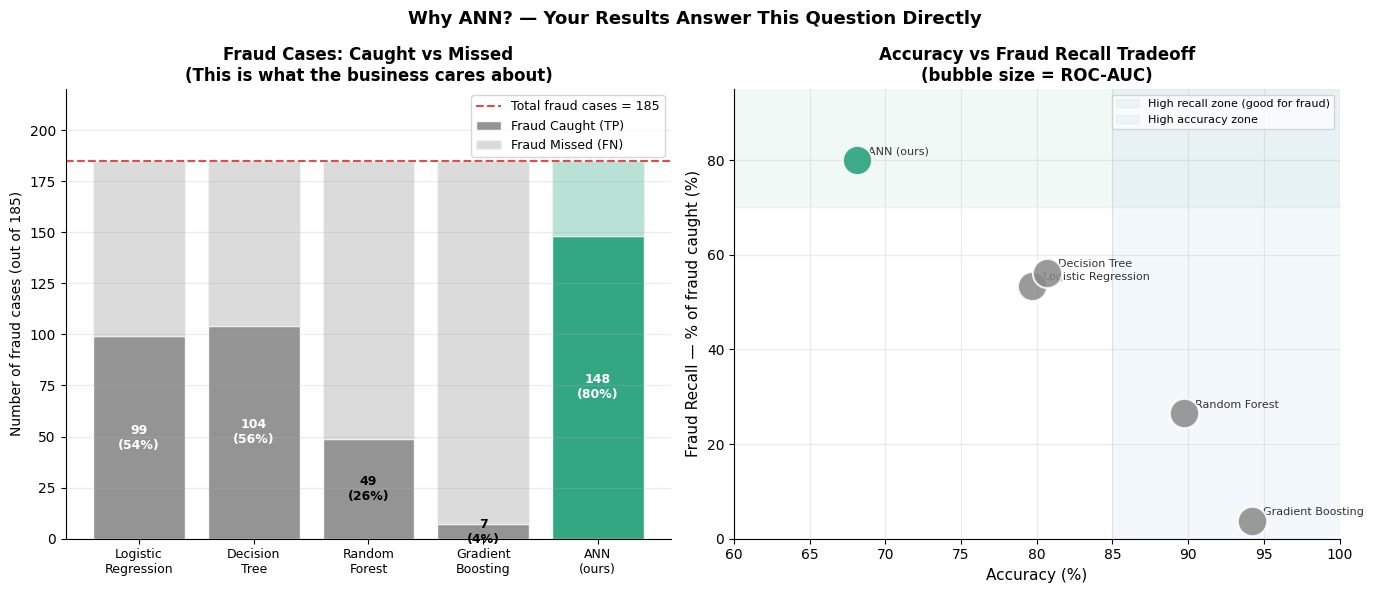

In [52]:
# Cell 15: The definitive answer — grounded in YOUR results
# This is what you say in your viva when asked
# "why ANN over ML models?"

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── The one chart that tells the whole story ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Why ANN? — Your Results Answer This Question Directly",
    fontsize=13, fontweight="bold"
)

models     = ["Logistic\nRegression", "Decision\nTree",
              "Random\nForest", "Gradient\nBoosting", "ANN\n(ours)"]
caught     = [99,  104, 49,  7,   148]   # TP
missed     = [86,  81,  136, 178, 37]    # FN
false_alarm= [539, 513, 182, 2,   947]

colors_bar = ["#888888","#888888","#888888","#888888","#1D9E75"]
x = np.arange(len(models))

# Left: fraud caught vs missed (the only metric that matters)
b1 = axes[0].bar(x, caught, color=colors_bar,
                 alpha=0.9, edgecolor="white",
                 label="Fraud Caught (TP)")
b2 = axes[0].bar(x, missed, bottom=caught,
                 color=colors_bar, alpha=0.3,
                 edgecolor="white", label="Fraud Missed (FN)")

axes[0].axhline(y=185, color="#E24B4A", ls="--", lw=1.5,
                label="Total fraud cases = 185")

for bar, c, m in zip(b1, caught, missed):
    pct = c / 185 * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 c / 2,
                 f"{c}\n({pct:.0f}%)",
                 ha="center", va="center",
                 fontsize=9, fontweight="bold",
                 color="white" if pct > 30 else "black")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel("Number of fraud cases (out of 185)")
axes[0].set_ylim(0, 220)
axes[0].set_title("Fraud Cases: Caught vs Missed\n"
                  "(This is what the business cares about)",
                  fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.25)
axes[0].spines[["top","right"]].set_visible(False)

# Right: accuracy vs fraud recall scatter
accuracy_vals = [79.7, 80.7, 89.7, 94.2, 68.1]
recall_vals   = [53.5, 56.2, 26.5,  3.8, 80.0]
auc_vals_all  = [80.26, 80.66, 82.60, 82.18, 80.72]

for i, (m, acc, rec, auc, color) in enumerate(zip(
        models, accuracy_vals, recall_vals,
        auc_vals_all, colors_bar)):
    size = 200 + auc * 3
    axes[1].scatter(acc, rec, s=size, color=color,
                    alpha=0.85, edgecolors="white", linewidth=1.5,
                    zorder=5)
    axes[1].annotate(
        m.replace("\n"," "),
        (acc, rec),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
        color="#333333"
    )

# Ideal zone
axes[1].axhspan(70, 100, alpha=0.06, color="#1D9E75",
                label="High recall zone (good for fraud)")
axes[1].axvspan(85, 100, alpha=0.06, color="#378ADD",
                label="High accuracy zone")

axes[1].set_xlabel("Accuracy (%)", fontsize=11)
axes[1].set_ylabel("Fraud Recall — % of fraud caught (%)", fontsize=11)
axes[1].set_title("Accuracy vs Fraud Recall Tradeoff\n"
                  "(bubble size = ROC-AUC)",
                  fontweight="bold")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(alpha=0.25)
axes[1].spines[["top","right"]].set_visible(False)
axes[1].set_xlim(60, 100)
axes[1].set_ylim(0, 95)

plt.tight_layout()
plt.show()

